In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import functools
import warnings
from  matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_val_score,cross_validate,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier 
import matplotlib.image as mpimg
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import math
from matplotlib import colors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
 warnings.simplefilter('ignore')

In [3]:
def minmax(aa):
    return functools.reduce(lambda mm,xx : ( min(mm[0],xx),max(mm[1],xx)) , aa, ( aa[0],aa[0],))


In [4]:
def my_ceil(a, precision=0):
    return np.round(a + 0.5 * 10**(-precision), precision)

def my_floor(a, precision=0):
    return np.round(a - 0.5 * 10**(-precision), precision)

def plot_images(images, texts, title):
    import matplotlib.pyplot as plt
    num_images = len(images)
    print(len(images))
    # Check if there are images to plot
    if num_images == 0:
        print(f"No images found for {title}. Skipping...")
        return  # Avoids creating an empty plot

    num_rows = (num_images + images_per_row - 1) // images_per_row  # Compute required rows

    fig, axs = plt.subplots(num_rows, images_per_row, figsize=(15, 3 * num_rows))
    fig.suptitle(title, fontsize=28)

    axs = axs.ravel()
    for idx in range(len(axs)):  # Iterate over the grid
        if idx < num_images:
            axs[idx].imshow(images[idx])
            axs[idx].set_title(texts[idx], fontsize=12)
            axs[idx].axis("off")
        else:
            axs[idx].axis("off")  # Hide empty subplots
            
def plot_allimages(images):
    import matplotlib.pyplot as plt
    num_images = len(images)
    print(len(images))
    # Check if there are images to plot
    if num_images == 0:
        print(f"No images found for {title}. Skipping...")
        return  # Avoids creating an empty plot

    num_rows = (num_images + images_per_row - 1) // images_per_row  # Compute required rows

    fig, axs = plt.subplots(num_rows, images_per_row, figsize=(15, 3 * num_rows))
    axs = axs.ravel()
    for idx in range(len(axs)):  # Iterate over the grid
        if idx < num_images:
            axs[idx].imshow(images[idx])
            axs[idx].set_title(str(idx+1), fontsize=12)
            axs[idx].axis("off")
        else:
            axs[idx].axis("off")  # Hide empty subplots
            
            
def convert_figures_to_images(figures):
    """
    Converts a list of Matplotlib figures into NumPy image arrays.
    """
    image_arrays = []
    for fig in figures:
        canvas = FigureCanvas(fig)
        canvas.draw()
        img_array = np.array(canvas.buffer_rgba())  # Convert figure to image array
        image_arrays.append(img_array)
    return image_arrays

def plot_images_V(figures):
    import matplotlib.pyplot as plt
    """
    Displays the velocity plots stored in `figures` as images.
    """
    num_images = len(figures)



    num_rows = (num_images + images_per_row_V - 1) // images_per_row_V  # Compute required rows
    fig, axs = plt.subplots(num_rows, images_per_row_V, figsize=(12, 3 * num_rows))
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    axs = axs.ravel()
    
    # Convert figures to image arrays
    image_arrays = convert_figures_to_images(figures)
    
    for idx in range(len(axs)):  # Iterate over the grid
        if idx < num_images:
            axs[idx].imshow(image_arrays[idx])
            axs[idx].axis("off")
        else:
            axs[idx].axis("off")  # Hide empty subplots

    plt.show()


def plot_images_dual(images1, images2,  title):#texts,
    print(len(images1),len(images2))
    num_images = (len(images1))  # Ensure same number of images
    image_arrays = convert_figures_to_images(images2)

    images_per_row = 4  # Set number of columns per row

    if num_images == 0:
        print(f"No images found for {title}. Skipping...")
        return  # Avoids creating an empty plot

    num_rows = (num_images + images_per_row - 1) // images_per_row  # Compute required rows

    fig, axs = plt.subplots(num_rows, images_per_row, figsize=(15, 3 * num_rows * 2))  # Double height
#    fig.suptitle(title, fontsize=28)

    axs = axs.ravel()
    
    for idx in range(len(axs)):  # Iterate over the grid
        if idx < num_images:
            # Create subplots inside each cell for two images
            subfig = axs[idx].inset_axes([0, 0, 1, 0.5])  # Bottom half
            subfig.imshow(images1[idx])
            subfig.axis("off")
#            axs[idx].set_title(texts[idx], fontsize=12)

            subfig2 = axs[idx].inset_axes([0, 0.5, 1, 0.5])  # Top half
            subfig2.imshow(image_arrays[idx])
            subfig2.axis("off")
            
        else:
            axs[idx].axis("off")  # Hide empty subplots

    plt.show()


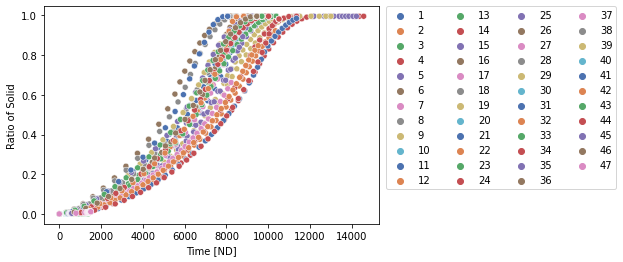

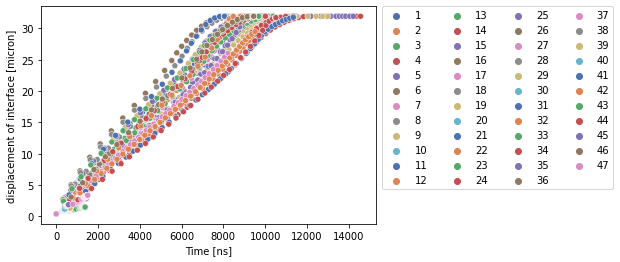

In [5]:
n=47
kissi=8e-8

data_new=[]
    
#data=pd.read_csv('1/step-time.txt',header=None,delimiter=' ',names=ll,index_col=None) #delimiter=' '


for i in range(n):
#    print("folder {}".format(i+1))
    flag = False  # Defining the flag variable+-
    direct=str(str(i+1)+"/step-time.txt")
    ll=['Step','Time [ND]', 'Number of Solid', 'Ratio of Solid']
    data=pd.DataFrame(np.loadtxt(direct, dtype=float),columns=ll)
    data = data.sort_values(by='Step')
    data.reset_index(inplace=True)

    data["Time [ns]"]=data["Time [ND]"]*1
    data["displacement of interface [micron]"]=np.sqrt(data["Number of Solid"])*kissi*0.8/1.0e-6
    data["Folder"]=i+1
    dx=1.0e-6
    dt=1.0e-9
    data_new.append(data)

final_df = pd.concat(data_new, ignore_index=True)
final_df.head()
sns.scatterplot(data=final_df, x="Time [ND]", y="Ratio of Solid", hue="Folder",palette="deep")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0, ncol=4)

plt.show()
sns.scatterplot(data=final_df, x="Time [ns]", y="displacement of interface [micron]", hue="Folder",palette="deep")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0, ncol=4)

final_df.head()
plt.show()

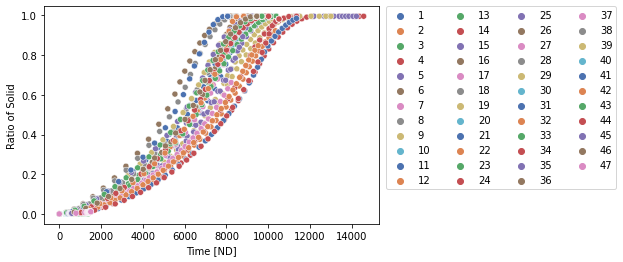

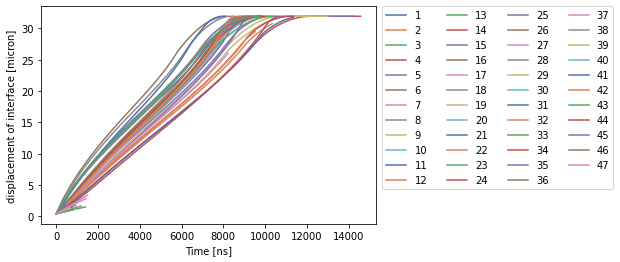

In [6]:
n=47
kissi=8e-8

data_new=[]
    
#data=pd.read_csv('1/step-time.txt',header=None,delimiter=' ',names=ll,index_col=None) #delimiter=' '


for i in range(n):
#    print("folder {}".format(i+1))
    flag = False  # Defining the flag variable+-
    direct=str(str(i+1)+"/step-time.txt")
    ll=['Step','Time [ND]', 'Number of Solid', 'Ratio of Solid']
    data=pd.DataFrame(np.loadtxt(direct, dtype=float),columns=ll)
    data = data.sort_values(by='Step')
    data.reset_index(inplace=True)

    data["Time [ns]"]=data["Time [ND]"]*1
    data["displacement of interface [micron]"]=np.sqrt(data["Number of Solid"])*kissi*0.8/1.0e-6
    data["Folder"]=i+1

    dx=1.0e-6
    dt=1.0e-9
    data_new.append(data)

final_df = pd.concat(data_new, ignore_index=True)
final_df.head()
sns.scatterplot(data=final_df, x="Time [ND]", y="Ratio of Solid", hue="Folder",palette="deep") 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0, ncol=4)

plt.show()
sns.lineplot(data=final_df, x="Time [ns]", y="displacement of interface [micron]", hue="Folder",palette="deep")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0, ncol=4)

final_df.head()
plt.show()

folder=1, V=3.3069, start=3, end=18, delta=-0.096, endtime=9745.708
folder=2, V=3.7492, start=6, end=36, delta=0.136, endtime=918.736
folder=3, V=1.6204, start=0, end=36, delta=-0.257, endtime=504.531
folder=4, V=2.7151, start=3, end=34, delta=-0.016, endtime=14565.858
folder=5, V=3.3822, start=4, end=14, delta=-0.085, endtime=9175.349
folder=6, V=1.4983, start=0, end=14, delta=-0.167, endtime=934.156
folder=7, V=3.3073, start=3, end=15, delta=-0.06, endtime=9654.071
folder=8, V=0.8485, start=0, end=15, delta=-0.266, endtime=844.088
folder=9, V=3.2218, start=3, end=34, delta=-0.01, endtime=10397.067
folder=10, V=3.3464, start=3, end=17, delta=0.014, endtime=10124.861
folder=11, V=3.2257, start=4, end=12, delta=-0.031, endtime=9842.587
folder=12, V=3.314, start=3, end=14, delta=-0.027, endtime=9709.863
folder=13, V=3.3669, start=3, end=13, delta=0.025, endtime=9812.473
folder=14, V=1.458, start=0, end=13, delta=-0.179, endtime=760.986
folder=15, V=3.1408, start=3, end=17, delta=-0.032, 

,index,Step,Time [ND],Number of Solid,Ratio of Solid,Time [ns],displacement of interface [micron],Folder,gamma,mu,delta,delta2,Tm,short_status,average dt (ns),V,Unsteady_time,r_ratio,stiffness_ratio
1760,0,0.0,0.010000,36.0,0.000144,0.010000,0.384000,45,0.077453,0.10957,0.245143,-0.012584,1048.3079,1.0,0.030528,1.487774,500.438156,0.606242,-0.572391
1761,30,500.0,424.558272,636.0,0.002544,424.558272,1.614019,45,0.077453,0.10957,0.245143,-0.012584,1048.3079,1.0,0.030528,1.487774,500.438156,0.606242,-0.572391
1762,2,1000.0,475.244132,694.0,0.002776,475.244132,1.686008,45,0.077453,0.10957,0.245143,-0.012584,1048.3079,1.0,0.030528,1.487774,500.438156,0.606242,-0.572391
1763,13,1500.0,491.991252,713.0,0.002852,491.991252,1.708932,45,0.077453,0.10957,0.245143,-0.012584,1048.3079,1.0,0.030528,1.487774,500.438156,0.606242,-0.572391
1764,23,2000.0,500.438156,725.0,0.002900,500.438156,1.723253,45,0.077453,0.10957,0.245143,-0.012584,1048.3079,1.0,0.030528,1.487774,500.438156,0.606242,-0.572391


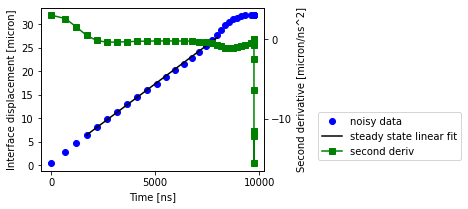

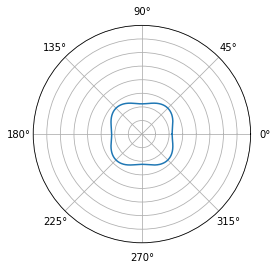

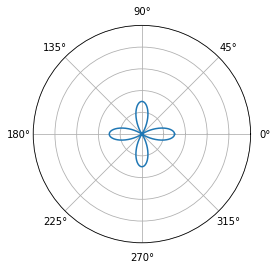

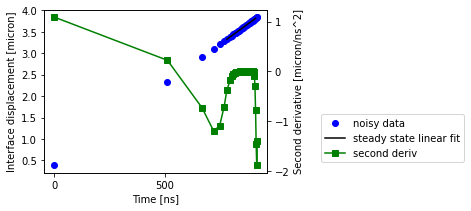

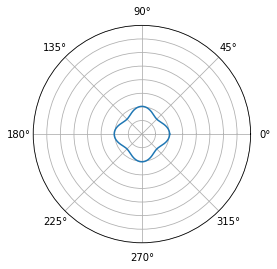

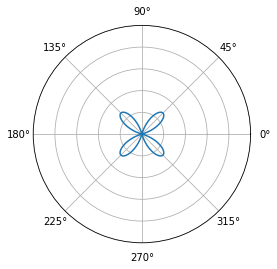

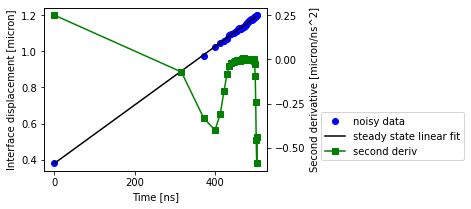

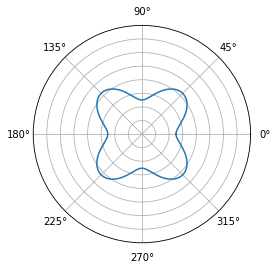

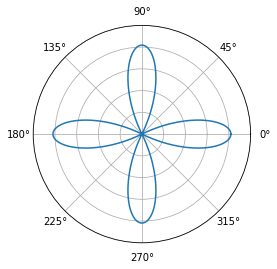

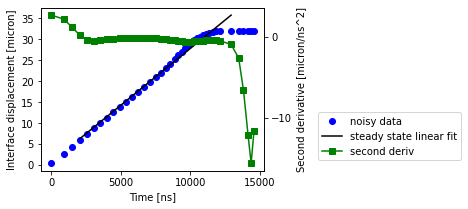

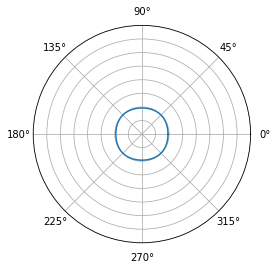

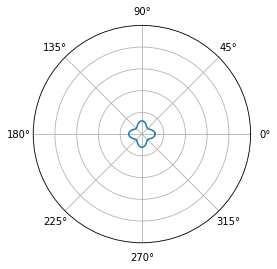

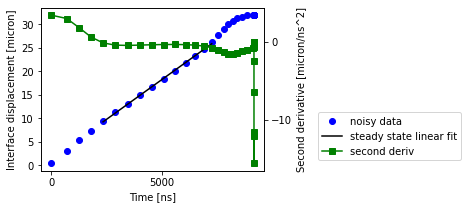

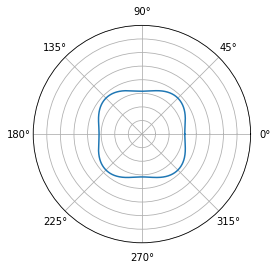

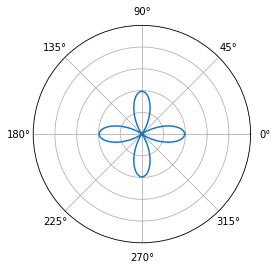

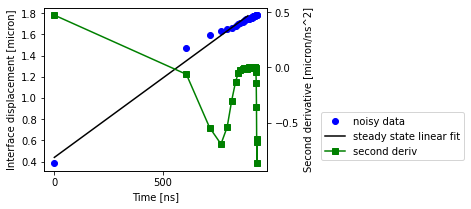

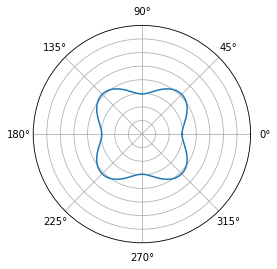

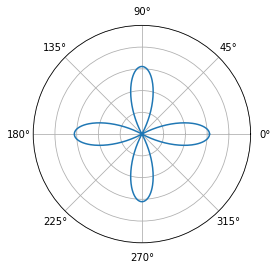

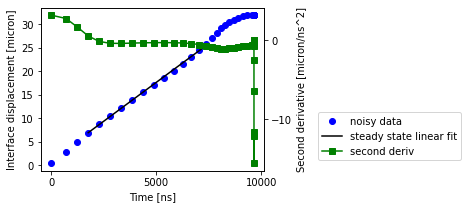

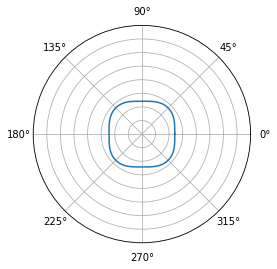

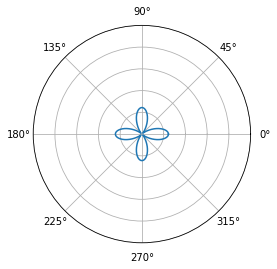

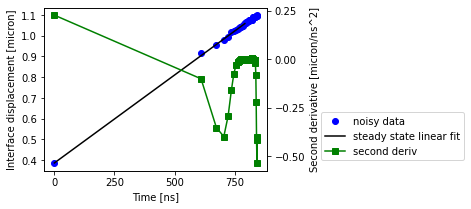

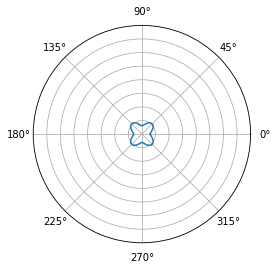

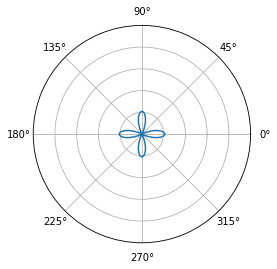

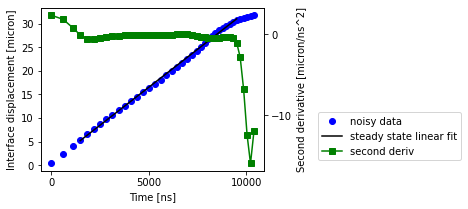

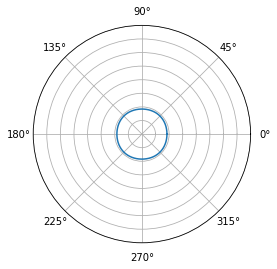

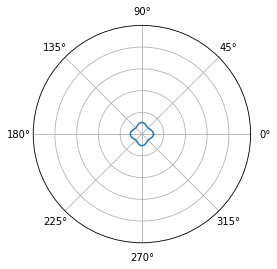

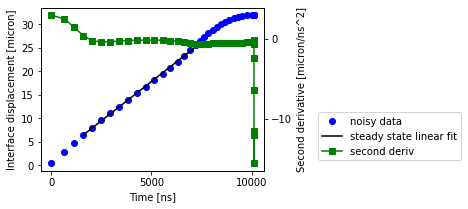

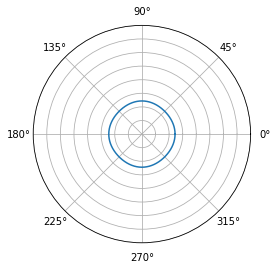

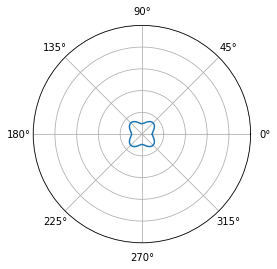

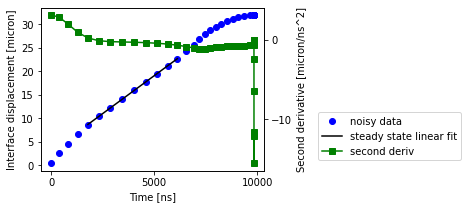

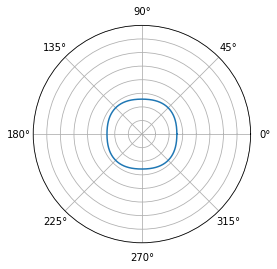

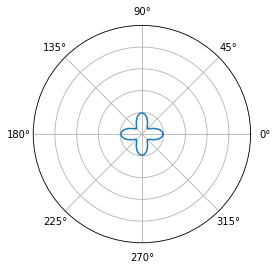

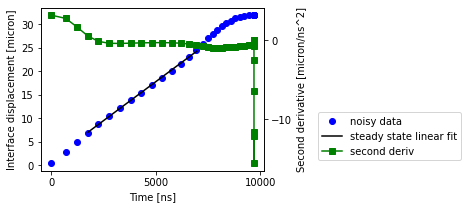

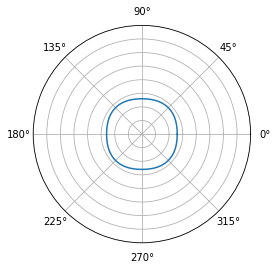

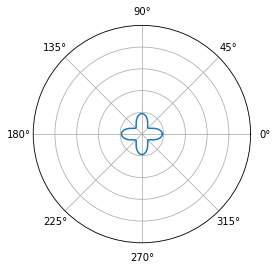

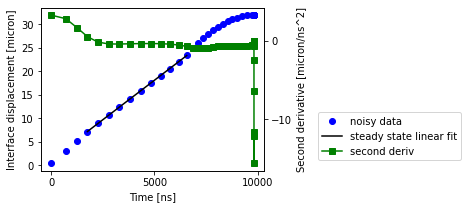

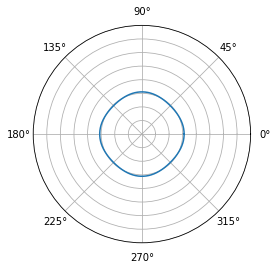

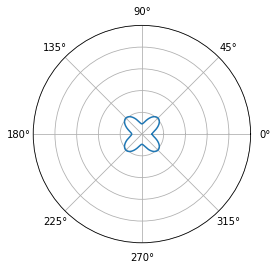

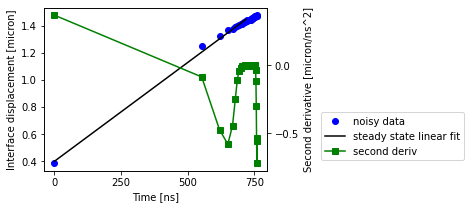

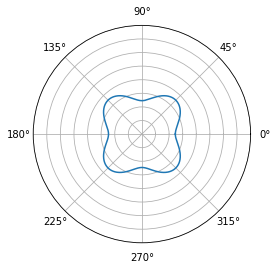

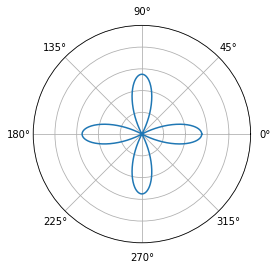

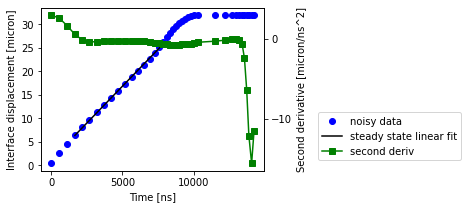

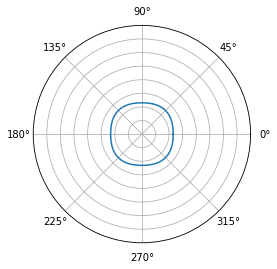

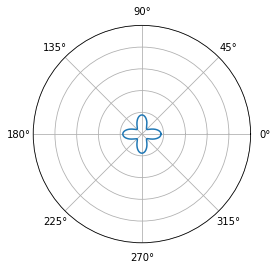

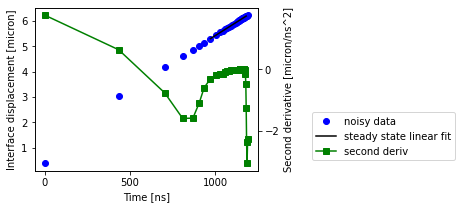

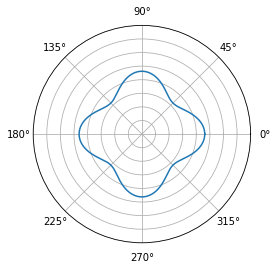

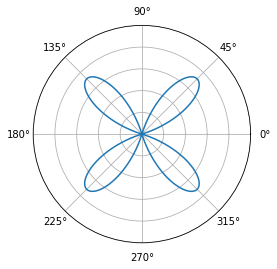

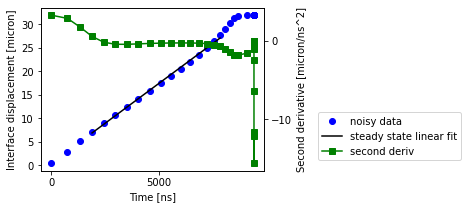

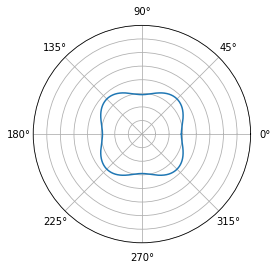

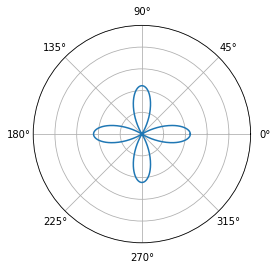

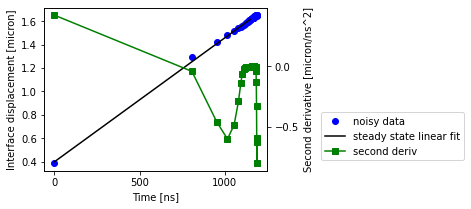

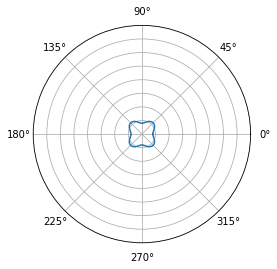

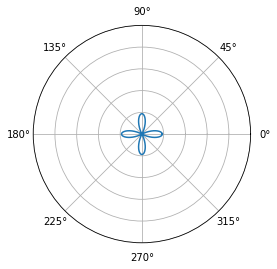

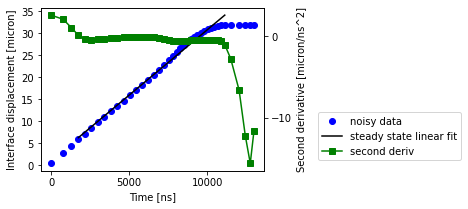

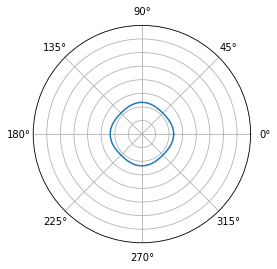

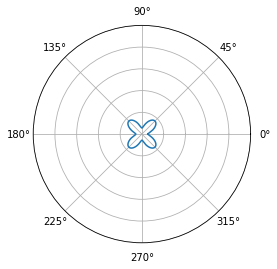

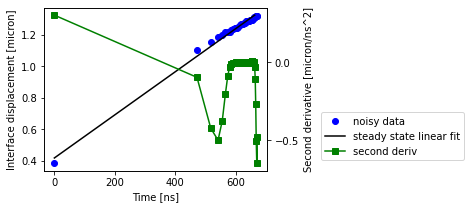

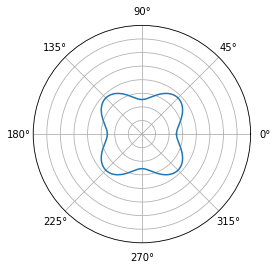

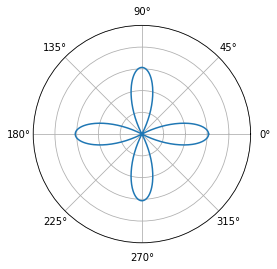

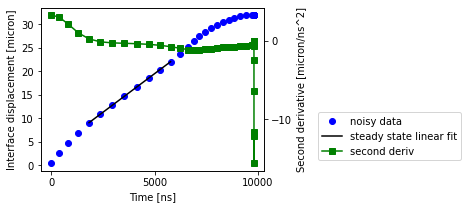

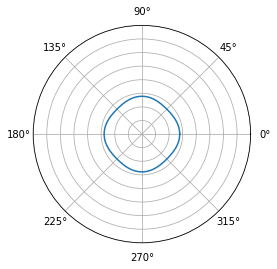

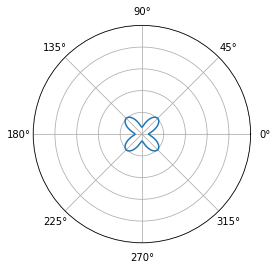

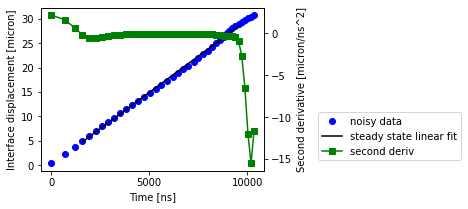

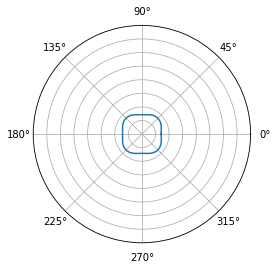

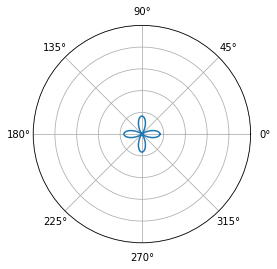

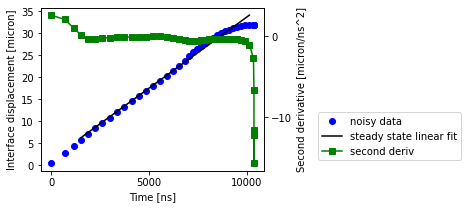

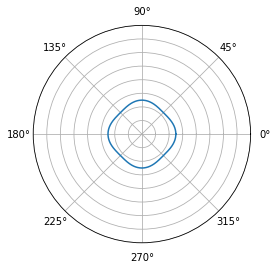

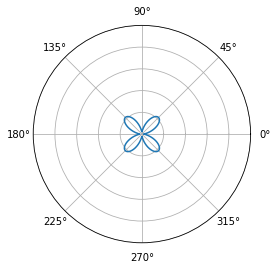

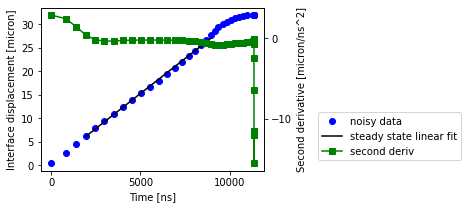

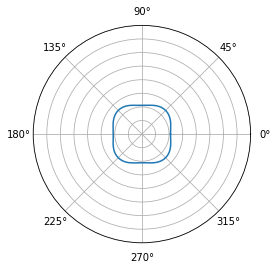

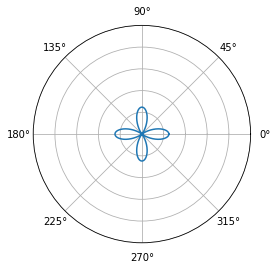

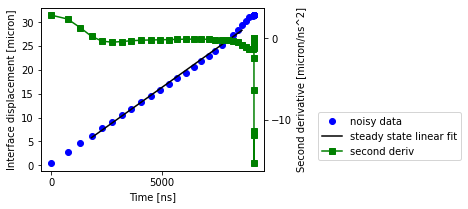

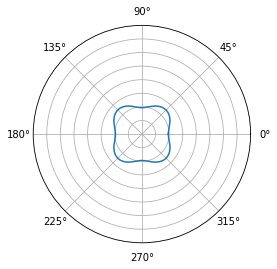

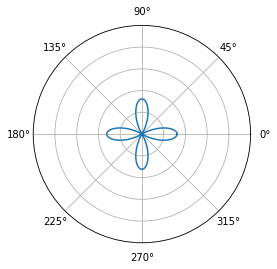

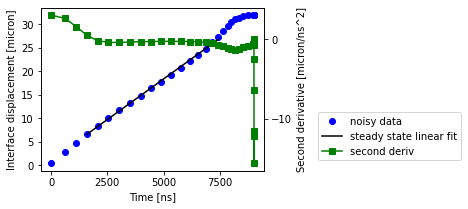

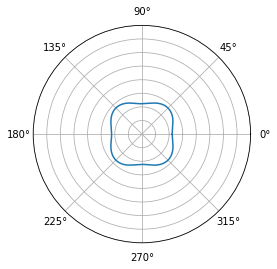

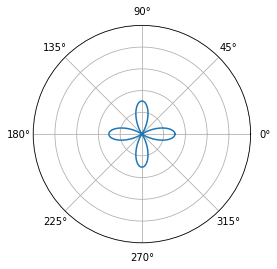

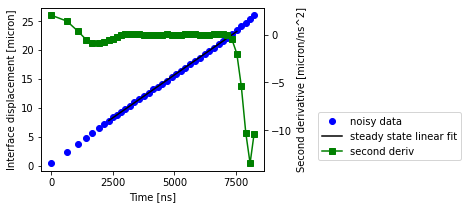

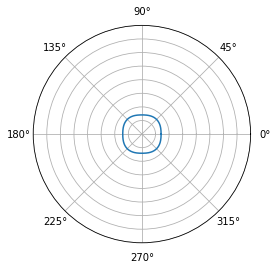

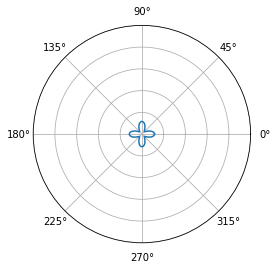

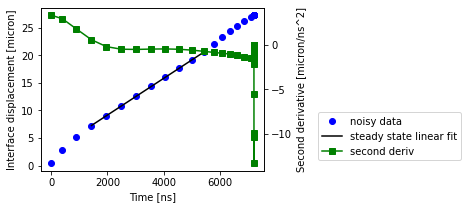

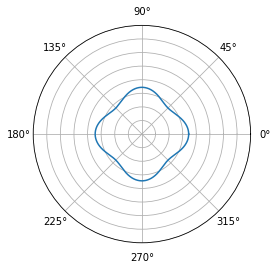

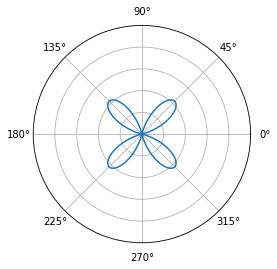

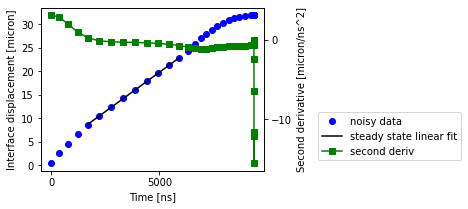

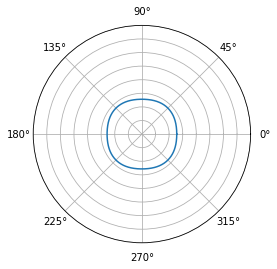

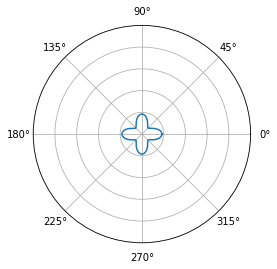

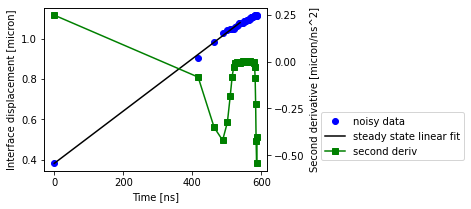

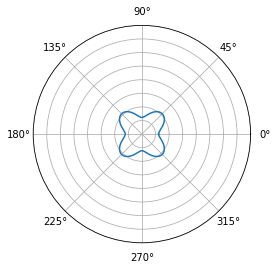

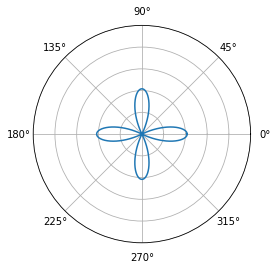

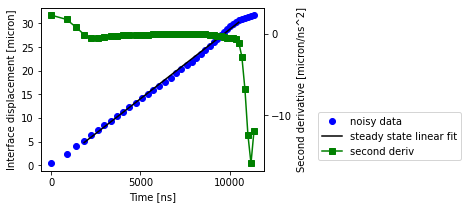

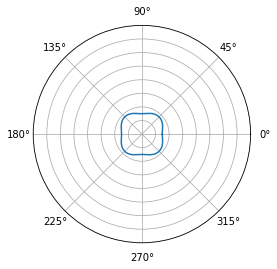

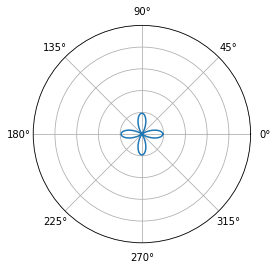

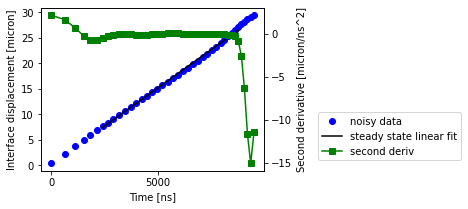

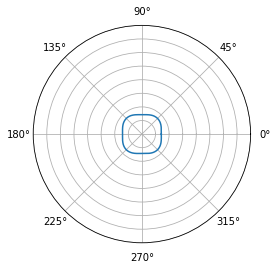

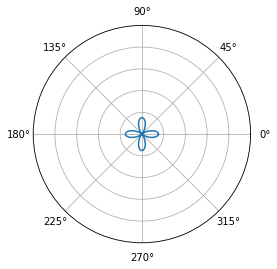

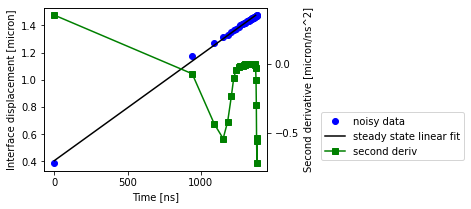

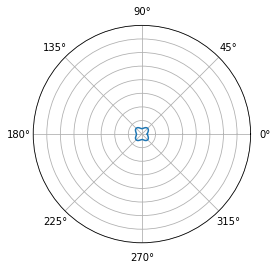

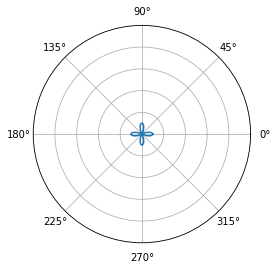

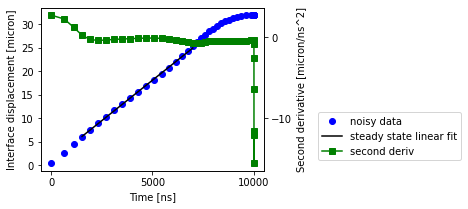

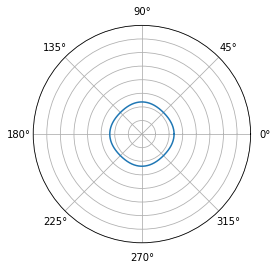

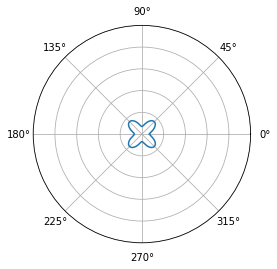

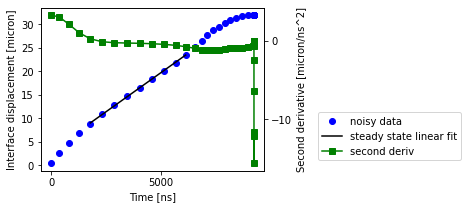

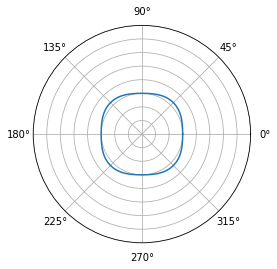

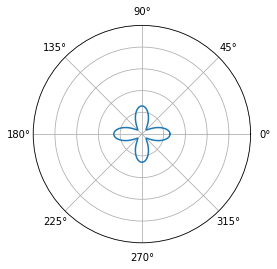

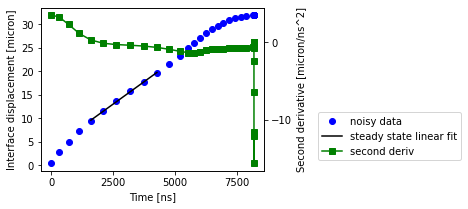

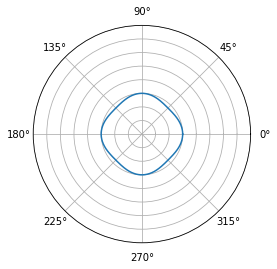

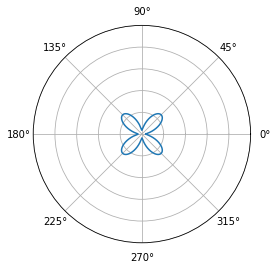

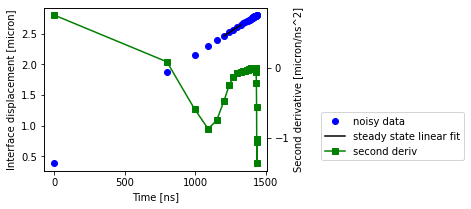

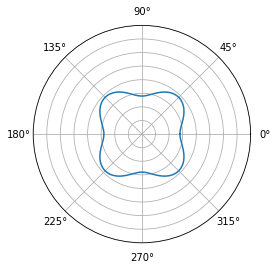

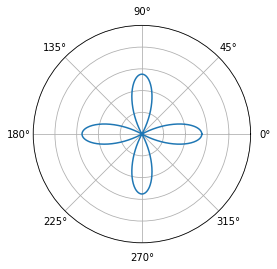

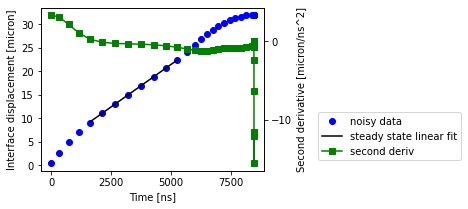

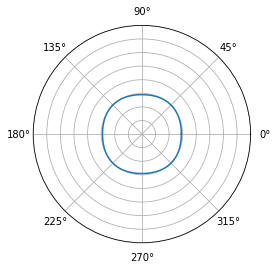

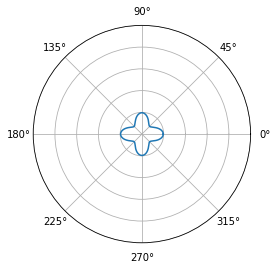

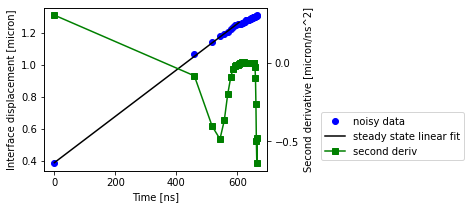

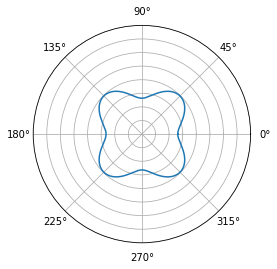

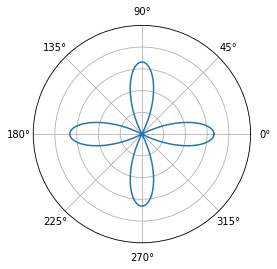

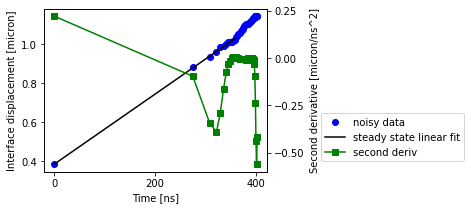

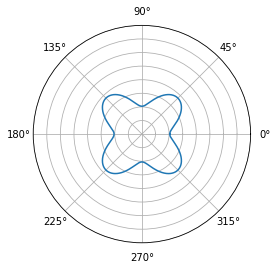

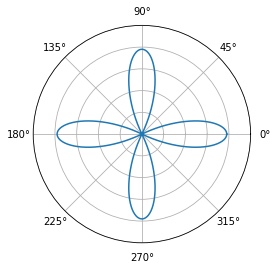

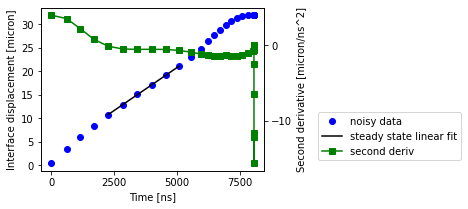

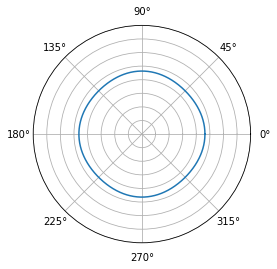

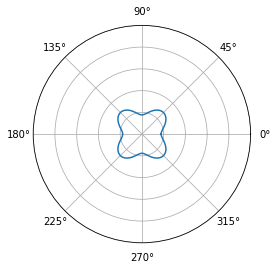

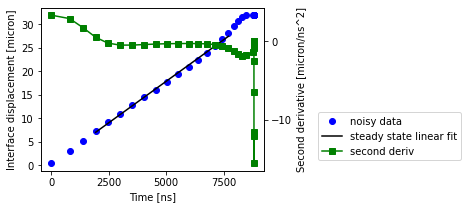

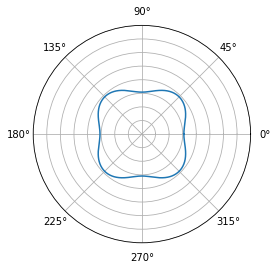

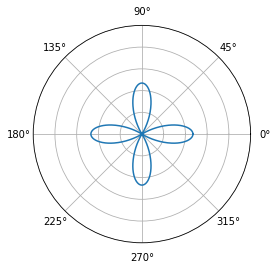

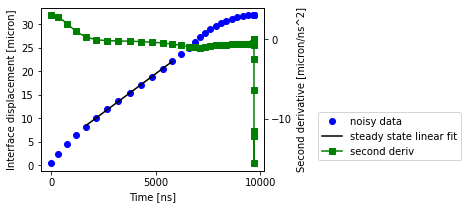

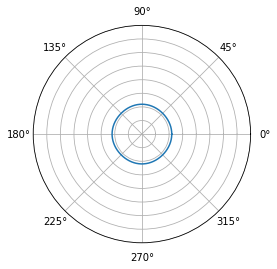

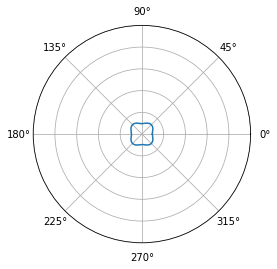

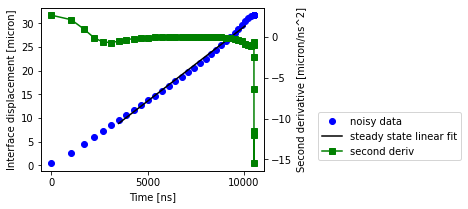

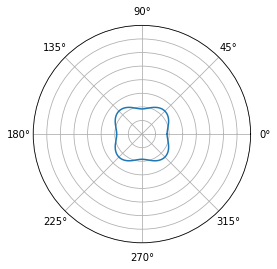

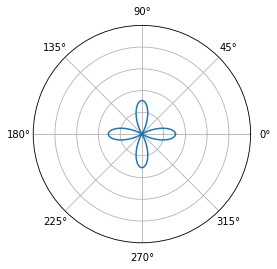

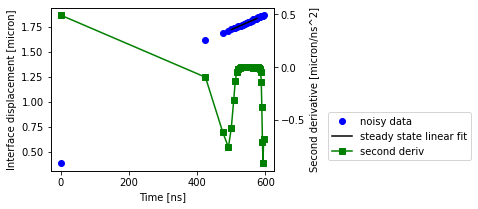

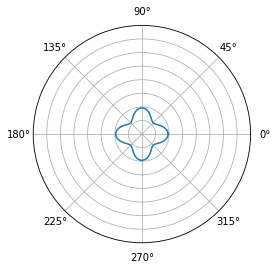

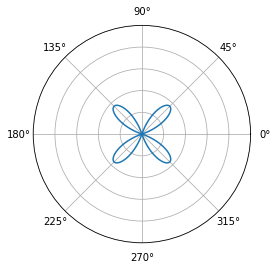

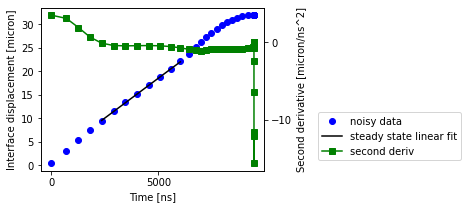

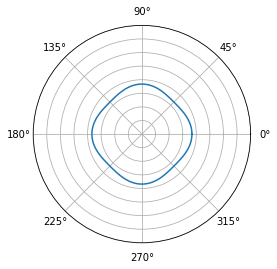

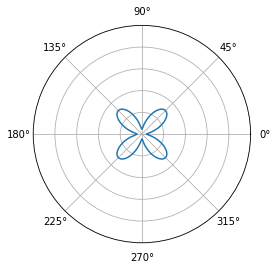

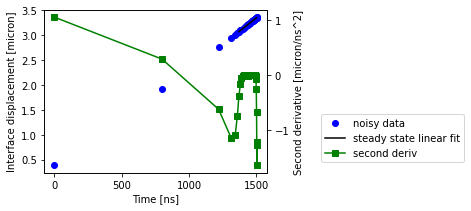

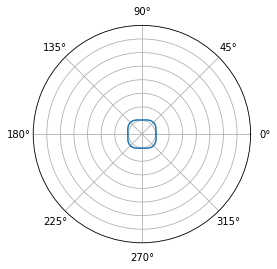

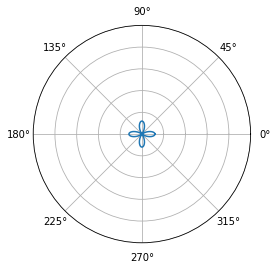

In [12]:
# second derivative
n=47
kissi=8e-8
images_per_row = 4
images_per_row_V = 3

gamma=[]
delta=[]
mu=[]
delta2=[]
V=[]
Tm=[]
Unsteady_time=[]
short_time=[]
long_time=[]
short_status=[]
average_dt=[]
short_images = []
long_images = []
all_images=[]
short_texts = []
long_texts = []
short_V=[]
long_V=[]

short_gamma=[]
long_gamma=[]
all_gamma=[]
long_index=[]
short_index=[]

short_stiffness=[]
long_stiffness=[]
all_stiffness=[]

stiffness_min_short=[]
stiffness_max_short=[]
r_min_short=[]
r_max_short=[]
all_r_ratio=[]
all_stiffness_ratio=[]

stiffness_min_long=[]
stiffness_max_long=[]
r_min_long=[]
r_max_long=[]


#data=pd.read_csv('1/step-time.txt',header=None,delimiter=' ',names=ll,index_col=None) #delimiter=' '

limit=0.6
limit_short=8000
dx=1.0e-6
dt=1.0e-9
theta = np.linspace(0, 2.0* np.pi, 1000)

for i in range(n):
#    print("folder {}".format(i+1))

    direct2=str(str(i+1)+"/gamma.dat")
    file = open(direct2, 'r')
    file.seek(6)
    gamma.append(float(file.read(10)))
    file.close()
    
    direct2=str(str(i+1)+"/delta.dat")
    file = open(direct2, 'r')
    file.seek(6)
    delta.append(float(file.read(10)))
    file.close()
    
    direct2=str(str(i+1)+"/delta2.dat")
    file = open(direct2, 'r')
    file.seek(7)
    delta2.append(float(file.read(11)))
    file.close()
    
    direct2=str(str(i+1)+"/tm.dat")
    file = open(direct2, 'r')
    file.seek(3)
    Tm.append(float(file.read(9)))
    file.close()
    
    direct2=str(str(i+1)+"/mu.dat")
    file = open(direct2, 'r')
    file.seek(3)
    mu.append(float(file.read(7)))
    file.close()

    ast_row =final_df[final_df["Folder"]==i+1].iloc[-1]["Time [ns]"]    
    aa=ast_row
    ddd =final_df[final_df["Folder"]==i+1].iloc[-1]["Time [ns]"]    
    dddd=final_df[final_df["Folder"]==i+1].iloc[-1]["Step"] 
    average_dt.append(ddd/dddd)
    if (aa<limit_short):
        short_time.append(i)
        short_status.append(1)
    else:
        long_time.append(i)
        short_status.append(0)

    
    y_n=list(final_df[final_df["Folder"]==i+1]["displacement of interface [micron]"])
    smooth_width=len(y_n)
    x1 = np.linspace(-7,7,smooth_width)
    norm = np.sum(np.exp(-x1**2)) * (x1[1]-x1[0]) # ad hoc normalization
    y1 = (4*x1**2 - 2) * np.exp(-x1**2) / smooth_width *8 #norm*(x1[1]-x1[0])
    y_conv = np.convolve(y_n, y1, mode="same")
    x=list(final_df[final_df["Folder"]==i+1]["Time [ns]"])
    for k in range(smooth_width-3):
        if (abs(y_conv[k])<limit and abs(y_conv[k+1])<limit and abs(y_conv[k+2])<limit):
            start=k
            break
#    print(start)
    for k in range (start,smooth_width-3):
        if (abs(y_conv[k])>limit and abs(y_conv[k+1])>limit and abs(y_conv[k+2])>limit):
            end=k
            break
#    print(end)
    a_ave=sum(list( y_conv[i] for i in range(start,end+1)))/len(list( y_conv[i] for i in range(start,end+1)))
#    print(a_ave,limit)
    x_fit=list( x[i] for i in range(start,end+1) )
    Unsteady_time.append(x[start])
    y_fit=list( y_n[i] for i in range(start,end+1) )
    m,b=np.polyfit(x_fit,y_fit,1)  
    V.append(m*dx/dt)
    print("folder="+str(i+1)+", V="+str(round (m*dx/dt,4))+", start="+str(start)+", end="+str(end)+
          ", delta="+str(round(delta[-1],3))+ ", endtime="+ str(round(aa,3)))
    fig, ax1 = plt.subplots(figsize=(4,3))
    ax2 = ax1.twinx()
    
    ax1.set_xlabel('Time [ns]')
    ax1.set_ylabel('Interface displacement [micron]')
    ax2.set_ylabel('Second derivative [micron/ns^2]')
    
    plt.locator_params(axis='both', nbins=4) 

    ax2.plot(x,y_conv,"s-", label = "second deriv", color='g')
    ax1.plot(x, y_n,"o", label = "noisy data", color='b')
    ax1.plot(x_fit,[m*x+b for x in x_fit],color="black",label="steady state linear fit" ) 
    fig.legend(bbox_to_anchor=(1.07, 0.15), loc='lower left')
    plt.ioff()  # Disable automatic display
    a=gamma[-1];b=delta[-1]
    # Compute r using the given equation
    r = a * (1 + b * np.cos(4 * theta))
    stiffness = a * (1 + b * np.cos(4 * theta))-16*a*b * np.cos(4 * theta)


    # Create polar plot
    fig2, ax2 = plt.subplots(subplot_kw={'projection': 'polar'})

    # Plot the function
    ax2.plot(theta, r)    
    ax2.set_yticklabels([])
    ax2.set_ylim(0, 0.4)  # Set r-axis limits

    
    fig3, ax3 = plt.subplots(subplot_kw={'projection': 'polar'})

    # Plot the function
    ax3.plot(theta, stiffness)    
    ax3.set_yticklabels([])
    ax3.set_ylim(0, 1)  # Set r-axis limits
    
    
    
    # Save figure to appropriate list
    if short_status[i] == 1:
        short_V.append(fig)
        short_gamma.append(fig2)
        short_stiffness.append(fig3)
        r_min_short.append(min(r))
        r_max_short.append(max(r))
        stiffness_min_short.append(min(stiffness))
        stiffness_max_short.append(max(stiffness))
        short_index.append(i)
    else:
        long_V.append(fig)
        long_gamma.append(fig2)
        long_stiffness.append(fig3)
        r_min_long.append(min(r))
        r_max_long.append(max(r))
        stiffness_min_long.append(min(stiffness))
        stiffness_max_long.append(max(stiffness))
        long_index.append(i)

    all_gamma.append(fig2)
    all_stiffness.append(fig3)

    all_r_ratio.append(min(r)/max(r))
    all_stiffness_ratio.append(min(stiffness)/max(stiffness))

#    plt.show()
    aa = round(0.5 * (start + end)) * 500
    image_filename = f"{i+1}/output_frame_{aa}_0000.jpeg"
    img = mpimg.imread(image_filename)  # Read image
        
    # Prepare text for annotation
    text = f"Gamma: {round(gamma[i], 3)}\nDelta: {round(delta[i], 3)}"
    if short_status[i] == 1:
        short_images.append(img)
        short_texts.append(text)
    else:
        long_images.append(img)
        long_texts.append(text)
    all_images.append(img)

    
    
for i in range(n):
    final_df.loc[final_df.Folder==i+1,"gamma"]=gamma[i]
    final_df.loc[final_df.Folder==i+1,"mu"]=mu[i]
    final_df.loc[final_df.Folder==i+1,"delta"]=delta[i]
    final_df.loc[final_df.Folder==i+1,"delta2"]=delta2[i]
    final_df.loc[final_df.Folder==i+1,"Tm"]=Tm[i]
    final_df.loc[final_df.Folder==i+1,"short_status"]=short_status[i]
    final_df.loc[final_df.Folder==i+1,"average dt (ns)"]=average_dt[i]
    final_df.loc[final_df.Folder==i+1,"V"]=V[i]
    final_df.loc[final_df.Folder==i+1,"Unsteady_time"]=Unsteady_time[i]
    final_df.loc[final_df.Folder==i+1,"r_ratio"]=all_r_ratio[i]
    final_df.loc[final_df.Folder==i+1,"stiffness_ratio"]=all_stiffness_ratio[i]


final_df[final_df["Folder"]==45].head()

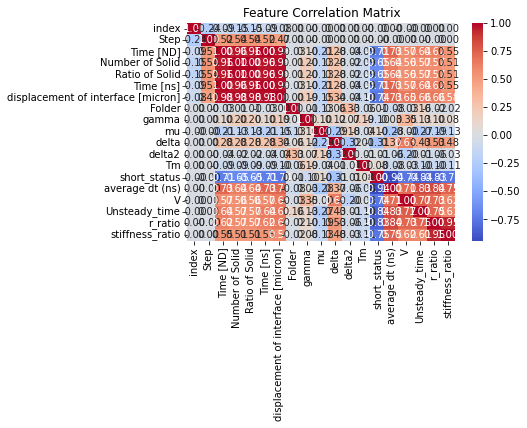

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [14]:
dict = {'V': V, 'SL interface free energy': gamma, 'SL interface free energy anisotropy': delta,'SL kinetic energy': mu,'SL kinetic energy anisotropy': delta2, 'Melting Temperature': Tm,"Unsteady_time":Unsteady_time,"short_status":short_status}  
data_cor = pd.DataFrame(dict)
data_cor.corrwith(data_cor['V'])
data_cor.corrwith(data_cor['Unsteady_time'])


V_short=[V[i] for i in short_time]
gamma_short=[gamma[i] for i in short_time]
delta_short=[delta[i] for i in short_time]
delta2_short=[delta2[i] for i in short_time]
mu_short=[mu[i] for i in short_time]
Tm_short=[Tm[i] for i in short_time]
Unsteady_time_short=[Unsteady_time[i] for i in short_time]

V_long=[V[i] for i in long_time]
gamma_long=[gamma[i] for i in long_time]
delta_long=[delta[i] for i in long_time]
delta2_long=[delta2[i] for i in long_time]
mu_long=[mu[i] for i in long_time]
Tm_long=[Tm[i] for i in long_time]
Unsteady_time_long=[Unsteady_time[i] for i in long_time]

dict = {'V': V_short, 'SL interface free energy': gamma_short, 'SL interface free energy anisotropy': delta_short,'SL kinetic energy': mu_short,'SL kinetic energy anisotropy': delta2_short, 'Melting Temperature': Tm_short,"Unsteady_time":Unsteady_time_short} 
   
data_short = pd.DataFrame(dict)
   
data_short.corrwith(data_short['V'])
dict = {'V': V_long, 'SL interface free energy': gamma_long, 'SL interface free energy anisotropy': delta_long,'SL kinetic energy': mu_long,'SL kinetic energy anisotropy': delta2_long, 'Melting Temperature': Tm_long,"Unsteady_time":Unsteady_time_long} 
   
data_long = pd.DataFrame(dict)
   
data_long.corrwith(data_long['V'])

V                                      1.000000
SL interface free energy               0.726929
SL interface free energy anisotropy    0.196807
SL kinetic energy                      0.507665
SL kinetic energy anisotropy           0.222491
Melting Temperature                   -0.063067
Unsteady_time                         -0.197101
dtype: float64

In [15]:
final_df_long = final_df[final_df["short_status"] == 0].copy()


1
2
Explained Variance Ratio: [0.5980622  0.2540526  0.13269558 0.01518962]


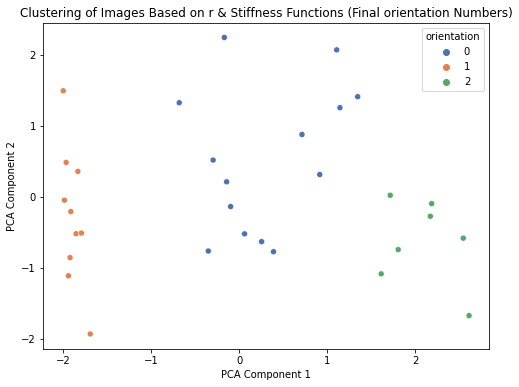

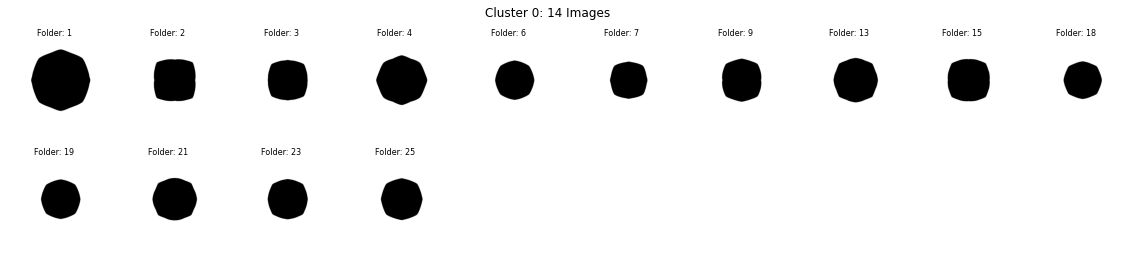

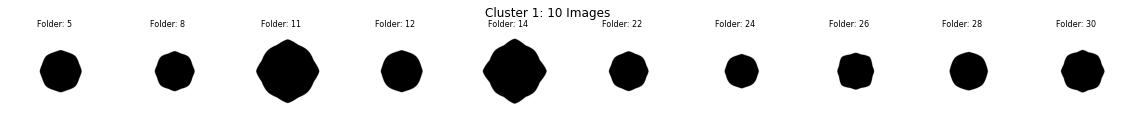

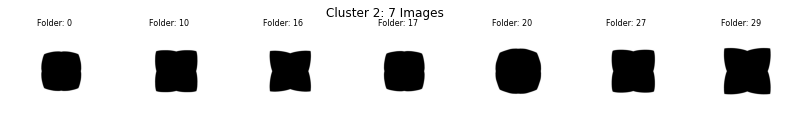

              r_ratio  delta_val  theta_r_min  delta2_val   Cluster  \
r_ratio      1.000000   0.797156     0.447378   -0.113606 -0.594820   
delta_val    0.797156   1.000000     0.815579   -0.076956 -0.288241   
theta_r_min  0.447378   0.815579     1.000000    0.029608  0.196875   
delta2_val  -0.113606  -0.076956     0.029608    1.000000  0.397136   
Cluster     -0.594820  -0.288241     0.196875    0.397136  1.000000   
orientation -0.594820  -0.288241     0.196875    0.397136  1.000000   

             orientation  
r_ratio        -0.594820  
delta_val      -0.288241  
theta_r_min     0.196875  
delta2_val      0.397136  
Cluster         1.000000  
orientation     1.000000  


In [16]:

# Load all images (assuming images are stored in a list called all_images)
num_samples = len(long_images)

# Compute r and stiffness functions
n = len(long_images)
theta = np.linspace(0, 2 * np.pi, 100)
r_functions = []
stiffness_functions = []

print("1")
for i in range(n):
    a = gamma_long[i]  # Last value of gamma
    b = delta_long[i]  # Last value of delta

    r = a * (1 + b * np.cos(4 * theta))
    stiffness = a * (1 + b * np.cos(4 * theta)) - 16 * a * b * np.cos(4 * theta)

    r_functions.append(r)
    stiffness_functions.append(stiffness)

# Feature extraction
features = []
print("2")

for i, (r, stiffness, delta_val,delta2_val,mu_val,gamma_val) in enumerate(zip(r_functions, stiffness_functions, delta_long,delta2_long,mu_long,gamma_long)):
    # Compute min/max ratio
    r_min, r_max = np.min(r), np.max(r)
    
    # Find corresponding theta values (convert to degrees)
    theta_r_min = theta[np.argmin(r)] * 180.0 / math.pi
    theta_r_max = theta[np.argmax(r)] * 180.0 / math.pi

    stiffness_min, stiffness_max = np.min(stiffness), np.max(stiffness)
    theta_stiffness_min = theta[np.argmin(stiffness)] * 180.0 / math.pi
    theta_stiffness_max = theta[np.argmax(stiffness)] * 180.0 / math.pi

    # Append features (only numerical values)
    features.append([ r_min/r_max, delta_val,theta_r_min,delta2_val])  #[delta_val, r_min/r_max]

    # Assign values to final_df_long based on index
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "r_min"] = r_min
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "r_max"] = r_max
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "theta_r_min"] = theta_r_min
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "stiffness_min"] = stiffness_min
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "stiffness_max"] = stiffness_max
    final_df_long.loc[final_df_long.Folder == (long_index[i] + 1), "theta_stiffness_min"] = theta_stiffness_min

# Convert features into DataFrame
feature_columns = [ "r_ratio", "delta_val","theta_r_min","delta2_val"] #["delta", "r_ratio"]
df_features = pd.DataFrame(features, columns=feature_columns)

# Ensure there are enough samples for PCA
if len(df_features) > 1:
    pca = PCA(n_components=min(len(feature_columns), len(df_features)))  # Adjust PCA components based on available samples
    
    # Standardize the features
    scaler = StandardScaler()
    df_features_scaled = scaler.fit_transform(df_features)
    
    # Apply PCA
    pca_features = pca.fit_transform(df_features_scaled)
    print("Explained Variance Ratio:", pca.explained_variance_ratio_)

    # Apply K-Means clustering with 3 clusters
    num_clusters = 3
    kmeans = KMeans(n_clusters=num_clusters, random_state=4892, init="k-means++", max_iter=3000)
    df_features["Cluster"] = kmeans.fit_predict(df_features_scaled)

    # Set "orientation" to be the same as "Cluster"
    df_features["orientation"] = df_features["Cluster"]

    # Visualize clusters in 2D PCA space
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=df_features["orientation"], palette="deep")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Clustering of Images Based on r & Stiffness Functions (Final orientation Numbers)")
    plt.legend(title="orientation")
    plt.show()

    # Plot all images in each cluster with Folder Name
    unique_orientations = sorted(df_features["orientation"].unique())

    for orientation_id in unique_orientations:
        cluster_indices = [i for i in range(num_samples) if df_features["orientation"][i] == orientation_id]
        cluster_images = [long_images[i] for i in cluster_indices]
        # Get corresponding folder names
        cluster_folders = final_df_long.loc[final_df_long.index[cluster_indices], "Folder"].values

        num_images = len(cluster_images)
        cols = min(10, num_images)  # Max 10 images per row
        rows = (num_images // cols) + (num_images % cols > 0)  # Calculate necessary rows
        
        plt.figure(figsize=(cols * 2, rows * 2))
        plt.suptitle(f"Cluster {orientation_id}: {num_images} Images")
        jj=0
        for idx, (img, folder) in enumerate(zip(cluster_images, cluster_folders)):
            plt.subplot(rows, cols, idx + 1)
            plt.imshow(img, cmap='gray')  # Adjust colormap based on image type
            plt.axis("off")
            plt.title(f"Folder: {cluster_indices[jj]}", fontsize=8)  # Display Folder name above each image
            jj+=1
            
        plt.show()
else:
    print("Not enough samples for PCA analysis.")

# Assign "orientation" to final_df_long based on Folder index
for i in range(n):
    ss = df_features["orientation"].iloc[i]
    final_df_long.loc[final_df_long.Folder == (long_index[i]+1), "orientation"] = ss

# Display first few rows of final_df_long with orientation column
print(df_features.corr())


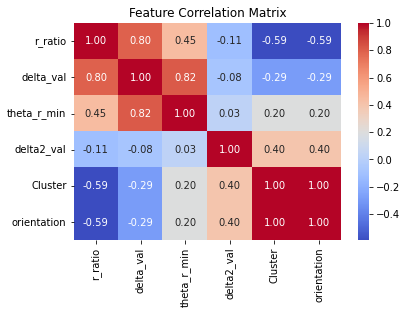

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df_features.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


# Load all images (assuming images are stored in a list called all_images)
num_samples = len(all_images)

# Compute r and stiffness functions
n = len(all_images)
theta = np.linspace(0, 2 * np.pi, 100)
r_functions = []
stiffness_functions = []

print("1")
for i in range(n):
    a = gamma[i]  # Last value of gamma
    b = delta[i]  # Last value of delta

    r = a * (1 + b * np.cos(4 * theta))
    stiffness = a * (1 + b * np.cos(4 * theta)) - 16 * a * b * np.cos(4 * theta)

    r_functions.append(r)
    stiffness_functions.append(stiffness)

# Feature extraction
features = []
print("2")

for i, (r, stiffness, delta_val) in enumerate(zip(r_functions, stiffness_functions, delta)):
    # Compute min/max ratio
    r_min, r_max = np.min(r), np.max(r)
    
    # Find corresponding theta values (convert to degrees)
    theta_r_min = theta[np.argmin(r)] * 180.0 / math.pi
    theta_r_max = theta[np.argmax(r)] * 180.0 / math.pi

    stiffness_min, stiffness_max = np.min(stiffness), np.max(stiffness)
    theta_stiffness_min = theta[np.argmin(stiffness)] * 180.0 / math.pi
    theta_stiffness_max = theta[np.argmax(stiffness)] * 180.0 / math.pi

    # Append features (only numerical values)
    features.append([delta_val, theta_r_min, r_min/r_max])

    # Assign values to final_df based on index
    final_df.loc[final_df.Folder == (i + 1), "r_min"] = r_min
    final_df.loc[final_df.Folder == (i + 1), "r_max"] = r_max
    final_df.loc[final_df.Folder == (i + 1), "theta_r_min"] = theta_r_min
    final_df.loc[final_df.Folder == (i + 1), "stiffness_min"] = stiffness_min
    final_df.loc[final_df.Folder == (i + 1), "stiffness_max"] = stiffness_max
    final_df.loc[final_df.Folder == (i + 1), "theta_stiffness_min"] = theta_stiffness_min

# Convert features into DataFrame
feature_columns = ["delta", "theta_r_min", "r_ratio"]
df_features = pd.DataFrame(features, columns=feature_columns)

# Ensure there are enough samples for PCA
if len(df_features) > 1:
    pca = PCA(n_components=min(3, len(df_features)))  # Adjust PCA components based on available samples
    
    # Standardize the features
    scaler = StandardScaler()
    df_features_scaled = scaler.fit_transform(df_features)
    
    # Apply PCA
    pca_features = pca.fit_transform(df_features_scaled)
    print("Explained Variance Ratio:", pca.explained_variance_ratio_)

    # Apply K-Means clustering with 3 clusters
    num_clusters = 3
    kmeans = KMeans(n_clusters=num_clusters, random_state=4892, init="k-means++", max_iter=3000)
    df_features["Cluster"] = kmeans.fit_predict(df_features_scaled)

    # Set "Orientation" to be the same as "Cluster"
    df_features["Orientation"] = df_features["Cluster"]

    # Visualize clusters in 2D PCA space
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=df_features["Orientation"], palette="deep")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Clustering of Images Based on r & Stiffness Functions (Final Orientation Numbers)")
    plt.legend(title="Orientation")
    plt.show()

    # Plot all images in each cluster with Folder Name
    unique_orientations = sorted(df_features["Orientation"].unique())

    for orientation_id in unique_orientations:
        cluster_indices = [i for i in range(num_samples) if df_features["Orientation"][i] == orientation_id]
        cluster_images = [all_images[i] for i in cluster_indices]
        # Get corresponding folder names
        cluster_folders = final_df.loc[final_df.index[cluster_indices], "Folder"].values

        num_images = len(cluster_images)
        cols = min(10, num_images)  # Max 10 images per row
        rows = (num_images // cols) + (num_images % cols > 0)  # Calculate necessary rows
        
        plt.figure(figsize=(cols * 2, rows * 2))
        plt.suptitle(f"Cluster {orientation_id}: {num_images} Images")
        jj=0
        for idx, (img, folder) in enumerate(zip(cluster_images, cluster_folders)):
            plt.subplot(rows, cols, idx + 1)
            plt.imshow(img, cmap='gray')  # Adjust colormap based on image type
            plt.axis("off")
            plt.title(f"Folder: {cluster_indices[jj]}", fontsize=8)  # Display Folder name above each image
            jj+=1
            
        plt.show()
else:
    print("Not enough samples for PCA analysis.")

# Assign "Orientation" to final_df based on Folder index
for i in range(n):
    ss = df_features["Orientation"].iloc[i]
    final_df.loc[final_df.Folder == i+1, "orientation"] = ss

# Display first few rows of final_df with Orientation column
print(df_features.corr())


In [18]:
n = len(long_images)

for i in range(n):
    aa=df_features["orientation"].iloc[i]
    if (aa==1):
        tmp=0
    elif (aa==0):
        tmp=1
    elif (aa==2):
        tmp=2
    print(aa,tmp)
    final_df_long.loc[final_df_long.Folder==(long_index[i]+1),"orientation new"]=tmp
    
    
print(df_features.corr())

2 2
0 1
0 1
0 1
0 1
1 0
0 1
0 1
1 0
0 1
2 2
1 0
1 0
0 1
1 0
0 1
2 2
2 2
0 1
0 1
2 2
0 1
1 0
0 1
1 0
0 1
1 0
2 2
1 0
2 2
1 0
              r_ratio  delta_val  theta_r_min  delta2_val   Cluster  \
r_ratio      1.000000   0.797156     0.447378   -0.113606 -0.594820   
delta_val    0.797156   1.000000     0.815579   -0.076956 -0.288241   
theta_r_min  0.447378   0.815579     1.000000    0.029608  0.196875   
delta2_val  -0.113606  -0.076956     0.029608    1.000000  0.397136   
Cluster     -0.594820  -0.288241     0.196875    0.397136  1.000000   
orientation -0.594820  -0.288241     0.196875    0.397136  1.000000   

             orientation  
r_ratio        -0.594820  
delta_val      -0.288241  
theta_r_min     0.196875  
delta2_val      0.397136  
Cluster         1.000000  
orientation     1.000000  


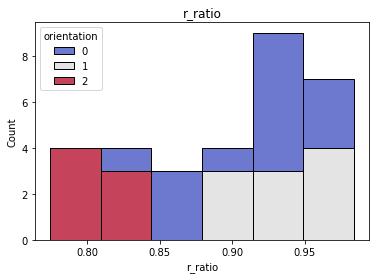

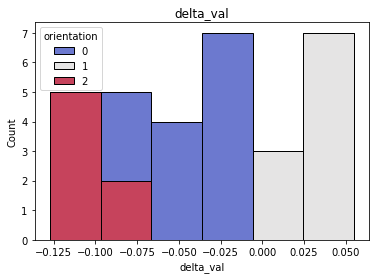

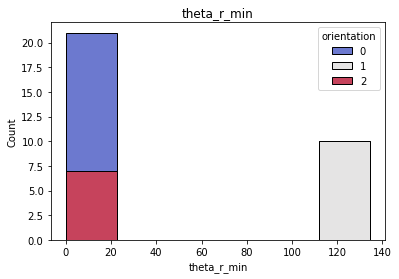

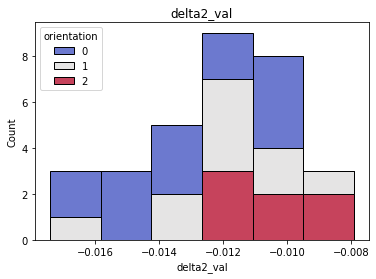

In [19]:
for i in range (len(feature_columns)):
    sns.histplot(x=feature_columns[i], hue='orientation',data=df_features, palette="coolwarm",multiple="stack")
    plt.title(feature_columns[i])
    plt.show()

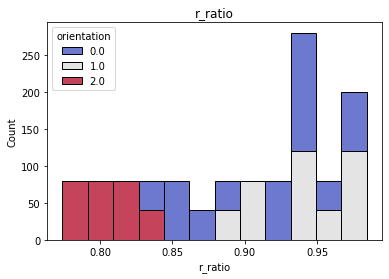

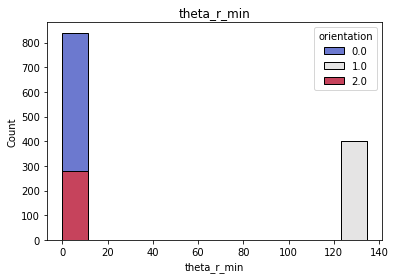

In [20]:
for i in range (len(feature_columns)):
    if feature_columns[i] in final_df_long.columns:
        sns.histplot(x=feature_columns[i], hue='orientation',data=final_df_long, palette="coolwarm",multiple="stack")
        plt.title(feature_columns[i])
        plt.show()

In [21]:
r_ratio_short=[]
stiffness_ratio_short=[]
r_ratio_long=[]
stiffness_ratio_long=[]

print(min(r_min_short),max(r_min_short))
for i in range(len(r_min_short)):
    r_ratio_short.append(r_min_short[i]/r_max_short[i])
    stiffness_ratio_short.append(stiffness_min_short[i]/stiffness_max_short[i])

for i in range(len(r_min_long)):
    r_ratio_long.append(r_min_long[i]/r_max_long[i])
    stiffness_ratio_long.append(stiffness_min_long[i]/stiffness_max_long[i])

0.0197837249691 0.16155846214584954


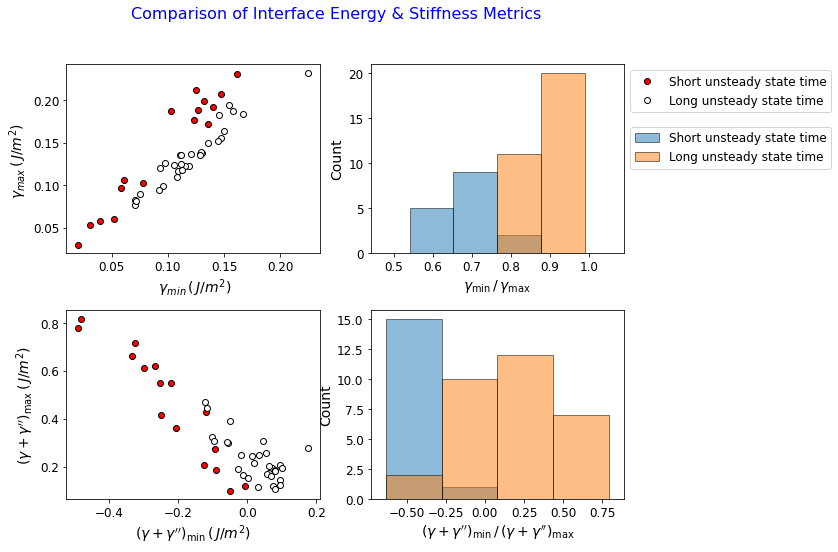

In [22]:
plt.rcParams.update({'axes.titlesize': 14,  # Titles
                     'axes.labelsize': 14,  # X and Y axis labels
                     'xtick.labelsize': 12,  # X tick labels
                     'ytick.labelsize': 12,
                     'legend.fontsize': 12,
                     'axes.titlecolor': 'blue'})  # Y tick labels})  # Legend font size


fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Create a 2x2 subplot grid
fig.subplots_adjust(wspace=0.2, hspace=0.3)  # Adjust spacing between subplots

# 1️⃣ Scatter Plot: Min vs. Max Interface Energy
axes[0, 0].plot(r_min_short, r_max_short, "o", color='red', markeredgecolor="black", label="Short unsteady state time") 
axes[0, 0].plot(r_min_long, r_max_long, "o", color='white', markeredgecolor="black", label="Long unsteady state time") 

axes[0, 0].set_xlabel(r" $\gamma_{min} \, (\, J/m^{2}) \,$")
axes[0, 0].set_ylabel(r"$\gamma_{max} \, (\, J/m^{2}) \,$ ")
axes[0, 0].legend(loc='upper left',bbox_to_anchor=(2.2, 1))

# 2️⃣ Histogram: Interface Energy Ratio
all_ratios = r_ratio_short + r_ratio_long
bins = np.linspace(math.floor(min(all_ratios)*100)/100.0, 
                   math.ceil(max(all_ratios)*100)/100.0, 5)

axes[0, 1].hist(r_ratio_short, bins=bins, alpha=0.5, edgecolor="black", label="Short unsteady state time")
axes[0, 1].hist(r_ratio_long, bins=bins, alpha=0.5, edgecolor="black", label="Long unsteady state time")

axes[0, 1].set_xlim([math.floor(min(all_ratios)*100)/100.0-0.1, math.ceil(max(all_ratios)*100)/100.0+0.1])
axes[0, 1].set_xlabel(r'$\gamma_{\min}\, / \, \gamma_{\max}$')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(loc='upper left',bbox_to_anchor=(1.00, 0.7))

# 3️⃣ Scatter Plot: Min vs. Max Stiffness
axes[1, 0].plot(stiffness_min_short, stiffness_max_short, "o", color='red', markeredgecolor="black", label="Short unsteady state time") 
axes[1, 0].plot(stiffness_min_long, stiffness_max_long, "o", color='white', markeredgecolor="black", label="Long unsteady state time") 

axes[1, 0].set_xlabel(r'$(\gamma + \gamma^{\prime\prime})_{\min} \, (\, J/m^{2}) \,$')
axes[1, 0].set_ylabel(r'$(\gamma + \gamma^{\prime\prime})_{\max} \, (\, J/m^{2}) \,$')
#axes[1, 0].legend(loc='upper left')

# 4️⃣ Histogram: Interface Stiffness Ratio
all_ratios = stiffness_ratio_short + stiffness_ratio_long
bins = np.linspace(math.floor(min(all_ratios)*100)/100.0, 
                   math.ceil(max(all_ratios)*100)/100.0, 5)

axes[1, 1].hist(stiffness_ratio_short, bins=bins, alpha=0.5, edgecolor="black", label="Short unsteady state time")
axes[1, 1].hist(stiffness_ratio_long, bins=bins, alpha=0.5, edgecolor="black", label="Long unsteady state time")

axes[1, 1].set_xlim([math.floor(min(all_ratios)*100)/100.0-0.1, math.ceil(max(all_ratios)*100)/100.0+0.1])
axes[1, 1].set_xlabel(r'$(\gamma + \gamma^{\prime\prime})_{\min} \, / \, (\gamma + \gamma^{\prime\prime})_{\max}$')
axes[1, 1].set_ylabel('Count')
#axes[1, 1].legend(loc='upper left')

plt.suptitle("Comparison of Interface Energy & Stiffness Metrics", color="blue",size=16)

plt.show()


In [23]:
final_df_long.head()

,index,Step,Time [ND],Number of Solid,Ratio of Solid,Time [ns],displacement of interface [micron],Folder,gamma,mu,...,r_ratio,stiffness_ratio,r_min,r_max,theta_r_min,stiffness_min,stiffness_max,theta_stiffness_min,orientation,orientation new
0,0,0.0,0.010000,36.0,0.000144,0.010000,0.384000,1,0.123058,0.13496,...,0.824772,-0.180465,0.111241,0.134869,0.0,-0.054108,0.300313,134.545455,2.0,2.0
1,30,500.0,688.804536,1874.0,0.007496,688.804536,2.770542,1,0.123058,0.13496,...,0.824772,-0.180465,0.111241,0.134869,0.0,-0.054108,0.300313,134.545455,2.0,2.0
2,2,1000.0,1216.154720,5465.0,0.021860,1216.154720,4.731241,1,0.123058,0.13496,...,0.824772,-0.180465,0.111241,0.134869,0.0,-0.054108,0.300313,134.545455,2.0,2.0
3,13,1500.0,1707.192987,10335.0,0.041340,1707.192987,6.506317,1,0.123058,0.13496,...,0.824772,-0.180465,0.111241,0.134869,0.0,-0.054108,0.300313,134.545455,2.0,2.0
4,23,2000.0,2190.205143,16356.0,0.065424,2190.205143,8.184997,1,0.123058,0.13496,...,0.824772,-0.180465,0.111241,0.134869,0.0,-0.054108,0.300313,134.545455,2.0,2.0


<AxesSubplot:xlabel='Folder', ylabel='delta'>

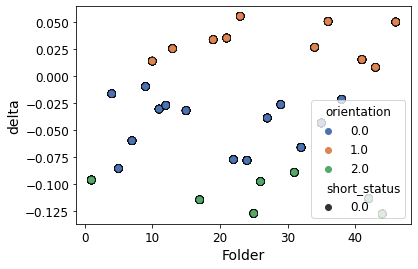

In [24]:
sns.scatterplot(data=final_df_long, x="Folder", y="delta", hue="orientation", style="short_status", 
                s=60, edgecolor="black", palette="deep")

Unique orientation values: (array([0., 1., 2.]), array([560, 400, 280]))
Unique Z_s2 classes: [0 1 2]
Unique Z_s3 classes: [0. 1. 2.]


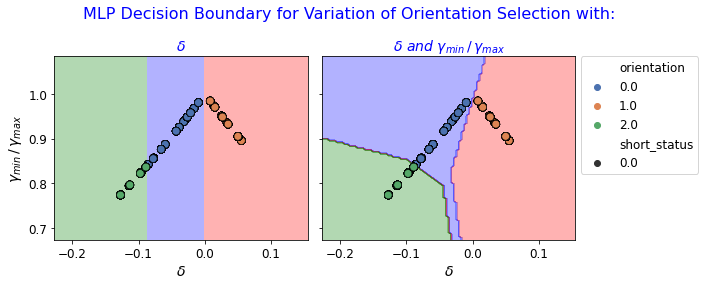

In [25]:

# 1️⃣ Extract Data (Keep all three orientation classes: 0, 1, 2)
filtered_df = final_df_long[final_df_long["orientation"].isin([0, 1, 2])]

# Features (delta only) and labels
X_s2 = filtered_df[["delta"]].values  # Use only "delta" for classification
y_s2 = filtered_df["orientation"].values  # Three-class classification

# Features (delta and r_ratio) and labels
X_s3 = filtered_df[["delta", "r_ratio"]].values  # Use both "delta" and "r_ratio"
y_s3 = filtered_df["orientation"].values  # Three-class classification

# ✅ Debugging: Check class distribution
print("Unique orientation values:", np.unique(y_s2, return_counts=True))

# 2️⃣ Split dataset into training and testing sets
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X_s2, y_s2, test_size=0.4, random_state=42, stratify=y_s2)
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X_s3, y_s3, test_size=0.4, random_state=42, stratify=y_s3)

# Normalize "delta"
scaler_s2 = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(X_train_s2)
X_test_s2 = scaler_s2.transform(X_test_s2)

# Normalize "delta and r_ratio"
scaler_s3 = StandardScaler()
X_train_s3 = scaler_s3.fit_transform(X_train_s3)
X_test_s3 = scaler_s3.transform(X_test_s3)

# 3️⃣ Train MLP Classifiers
mlp_s2 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s2.fit(X_train_s2, y_train_s2)

mlp_s3 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s3.fit(X_train_s3, y_train_s3)

# 4️⃣ Generate Meshgrid for Decision Boundaries
delta_min, delta_max = X_s2.min() - 0.1, X_s2.max() + 0.1
r_ratio_min, r_ratio_max = filtered_df["r_ratio"].min() - 0.1, filtered_df["r_ratio"].max() + 0.1

xx_s2, yy_s2 = np.meshgrid(np.linspace(delta_min, delta_max, 300), np.linspace(r_ratio_min, r_ratio_max, 300))
xx_s3, yy_s3 = np.meshgrid(np.linspace(delta_min, delta_max, 100), np.linspace(r_ratio_min, r_ratio_max, 100))

# Scale only "delta" for classification
xx_s2_scaled = scaler_s2.transform(xx_s2.reshape(-1, 1))  # Reshape required

# Predict decision boundaries
Z_s2 = np.argmax(mlp_s2.predict_proba(xx_s2_scaled), axis=1).reshape(xx_s2.shape)  # Uses only delta
Z_s3 = mlp_s3.predict(scaler_s3.transform(np.c_[xx_s3.ravel(), yy_s3.ravel()])).reshape(xx_s3.shape)  # Uses delta + r_ratio

# ✅ Debugging: Ensure classifier predicts three classes
print("Unique Z_s2 classes:", np.unique(Z_s2))
print("Unique Z_s3 classes:", np.unique(Z_s3))

# 5️⃣ Plot Subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4),sharey=True)
fig.suptitle(r"MLP Decision Boundary for Variation of Orientation Selection with:",size=16,color="blue")
# Custom colormap for three classes
cmap_custom = colors.ListedColormap(["blue", "red", "green"])

# (Left) Decision Boundary Based on Delta Only
axes[0].contourf(xx_s2, yy_s2, Z_s2, alpha=0.3, cmap=cmap_custom)  
sns.scatterplot(data=filtered_df, x="delta", y="r_ratio", hue="orientation", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[0])
axes[0].set_title(r"$\delta$")
axes[0].set_xlabel(r"$\delta$")
axes[0].set_ylabel(r'$\gamma_{min} \, / \, \gamma_{max}$')

# (Right) Decision Boundary Based on Delta & r_ratio
axes[1].contourf(xx_s3, yy_s3, Z_s3, alpha=0.3, cmap=cmap_custom)
sns.scatterplot(data=filtered_df, x="delta", y="r_ratio", hue="orientation", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[1])
axes[1].set_title(r"$\delta \  and \  \gamma_{min} \, / \, \gamma_{max}$")
axes[1].set_xlabel(r"$\delta$")
axes[1].set_ylabel("rmin/rmax")

# Adjust Legends
#axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0].legend_.remove()
plt.tight_layout()
plt.savefig( f"figures/orientation_delta_r-ratio.png", dpi=1200,bbox_inches='tight', facecolor='white')

plt.show()


Unique short_status values: (array([0., 1.]), array([1240,  640]))
Unique Z_s6 classes: [0 1]
Unique Z_s7 classes: [0. 1.]


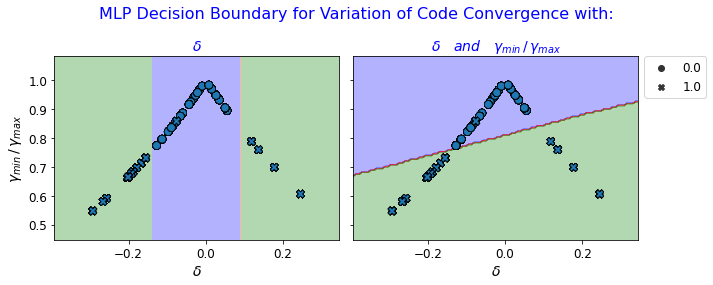

In [26]:
# 1️⃣ Extract Data (Keep all three orientation classes: 0, 1, 2)
filtered_df = final_df[final_df["short_status"].isin([0, 1])]

# Features (delta only) and labels
X_s6 = filtered_df[["delta"]].values  # Use only "delta" for classification
y_s6 = filtered_df["short_status"].values  # Three-class classification

# Features (delta and r_ratio) and labels
X_s7 = filtered_df[["delta", "r_ratio"]].values  # Use both "delta" and "r_ratio"
y_s7 = filtered_df["short_status"].values  # Three-class classification

# ✅ Debugging: Check class distribution
print("Unique short_status values:", np.unique(y_s6, return_counts=True))

# 2️⃣ Split dataset into training and testing sets
X_train_s6, X_test_s6, y_train_s6, y_test_s6 = train_test_split(X_s6, y_s6, test_size=0.2, random_state=42, stratify=y_s6)
X_train_s7, X_test_s7, y_train_s7, y_test_s7 = train_test_split(X_s7, y_s7, test_size=0.2, random_state=42, stratify=y_s7)

# Normalize "delta"
scaler_s6 = StandardScaler()
X_train_s6 = scaler_s6.fit_transform(X_train_s6)
X_test_s6 = scaler_s6.transform(X_test_s6)

# Normalize "delta and r_ratio"
scaler_s7 = StandardScaler()
X_train_s7 = scaler_s7.fit_transform(X_train_s7)
X_test_s7 = scaler_s7.transform(X_test_s7)

# 3️⃣ Train MLP Classifiers
mlp_s6 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s6.fit(X_train_s6, y_train_s6)

mlp_s7 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=5000, random_state=42, learning_rate_init=0.01)
mlp_s7.fit(X_train_s7, y_train_s7)

# 4️⃣ Generate Meshgrid for Decision Boundaries
delta_min, delta_max = X_s6.min() - 0.1, X_s6.max() + 0.1
r_ratio_min, r_ratio_max = filtered_df["r_ratio"].min() - 0.1, filtered_df["r_ratio"].max() + 0.1

xx_s6, yy_s6 = np.meshgrid(np.linspace(delta_min, delta_max, 300), np.linspace(r_ratio_min, r_ratio_max, 300))
xx_s7, yy_s7 = np.meshgrid(np.linspace(delta_min, delta_max, 100), np.linspace(r_ratio_min, r_ratio_max, 100))

# Scale only "delta" for classification
xx_s6_scaled = scaler_s6.transform(xx_s6.reshape(-1, 1))  # Reshape required

# Predict decision boundaries
Z_s6 = np.argmax(mlp_s6.predict_proba(xx_s6_scaled), axis=1).reshape(xx_s6.shape)  # Uses only delta
Z_s7 = mlp_s7.predict(scaler_s7.transform(np.c_[xx_s7.ravel(), yy_s7.ravel()])).reshape(xx_s7.shape)  # Uses delta + r_ratio

# ✅ Debugging: Ensure classifier predicts three classes
print("Unique Z_s6 classes:", np.unique(Z_s6))
print("Unique Z_s7 classes:", np.unique(Z_s7))

# 5️⃣ Plot Subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4),sharey=True)
fig.suptitle(r"MLP Decision Boundary for Variation of Code Convergence with:",size=16,color="blue")

# Custom colormap for three classes
cmap_custom = colors.ListedColormap(["blue", "red", "green"])

# (Left) Decision Boundary Based on Delta Only
axes[0].contourf(xx_s6, yy_s6, Z_s6, alpha=0.3, cmap=cmap_custom)  
sns.scatterplot(data=filtered_df, x="delta", y="r_ratio", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[0])
axes[0].set_title(r"$\delta$")
axes[0].set_xlabel(r"$\delta$")
axes[0].set_ylabel(r'$\gamma_{min} \, / \, \gamma_{max}$')

# (Right) Decision Boundary Based on Delta & r_ratio
axes[1].contourf(xx_s7, yy_s7, Z_s7, alpha=0.3, cmap=cmap_custom)
sns.scatterplot(data=filtered_df, x="delta", y="r_ratio", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[1])
axes[1].set_title(r"$\delta \quad and \quad \gamma_{min} \, / \, \gamma_{max}$")
axes[1].set_xlabel(r"$\delta$")
axes[1].set_ylabel(r'$\gamma_{min} \, / \, \gamma_{max}$')

# Adjust Legends
#axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0].legend_.remove()
plt.tight_layout()
plt.savefig( f"figures/convergence_delta_r-ratio.png", dpi=1200,bbox_inches='tight', facecolor='white')

plt.show()

Unique orientation values: (array([0., 1., 2.]), array([560, 400, 280]))
Unique Z_s4 classes: [0 1 2]
Unique Z_s5 classes: [0. 1. 2.]


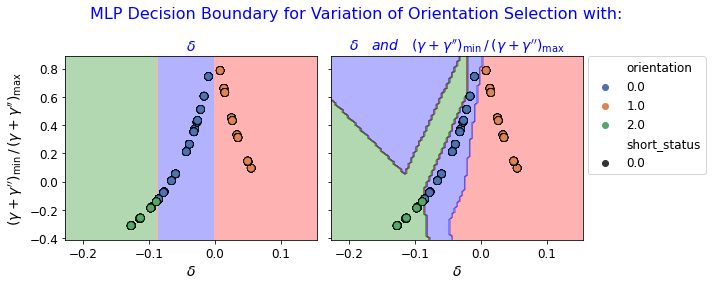

In [27]:

# 1️⃣ Extract Data (Keep all three orientation classes: 0, 1, 2)
filtered_df = final_df_long[final_df_long["orientation"].isin([0, 1, 2])]

# Features (delta only) and labels
X_s4 = filtered_df[["delta"]].values  # Use only "delta" for classification
y_s4 = filtered_df["orientation"].values  # Three-class classification

# Features (delta and stiffness_ratio) and labels
X_s5 = filtered_df[["delta", "stiffness_ratio"]].values  # Use both "delta" and "stiffness_ratio"
y_s5 = filtered_df["orientation"].values  # Three-class classification

# ✅ Debugging: Check class distribution
print("Unique orientation values:", np.unique(y_s4, return_counts=True))

# 2️⃣ Split dataset into training and testing sets
X_train_s4, X_test_s4, y_train_s4, y_test_s4 = train_test_split(X_s4, y_s4, test_size=0.2, random_state=42, stratify=y_s4)
X_train_s5, X_test_s5, y_train_s5, y_test_s5 = train_test_split(X_s5, y_s5, test_size=0.2, random_state=42, stratify=y_s5)

# Normalize "delta"
scaler_s4 = StandardScaler()
X_train_s4 = scaler_s4.fit_transform(X_train_s4)
X_test_s4 = scaler_s4.transform(X_test_s4)

# Normalize "delta and stiffness_ratio"
scaler_s5 = StandardScaler()
X_train_s5 = scaler_s5.fit_transform(X_train_s5)
X_test_s5 = scaler_s5.transform(X_test_s5)

# 3️⃣ Train MLP Classifiers
mlp_s4 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s4.fit(X_train_s4, y_train_s4)

mlp_s5 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu", max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s5.fit(X_train_s5, y_train_s5)

# 4️⃣ Generate Meshgrid for Decision Boundaries
delta_min, delta_max = X_s4.min() - 0.1, X_s4.max() + 0.1
stiffness_ratio_min, stiffness_ratio_max = filtered_df["stiffness_ratio"].min() - 0.1, filtered_df["stiffness_ratio"].max() + 0.1

xx_s4, yy_s4 = np.meshgrid(np.linspace(delta_min, delta_max, 300), np.linspace(stiffness_ratio_min, stiffness_ratio_max, 300))
xx_s5, yy_s5 = np.meshgrid(np.linspace(delta_min, delta_max, 100), np.linspace(stiffness_ratio_min, stiffness_ratio_max, 100))

# Scale only "delta" for classification
xx_s4_scaled = scaler_s4.transform(xx_s4.reshape(-1, 1))  # Reshape required

# Predict decision boundaries
Z_s4 = np.argmax(mlp_s4.predict_proba(xx_s4_scaled), axis=1).reshape(xx_s4.shape)  # Uses only delta
Z_s5 = mlp_s5.predict(scaler_s5.transform(np.c_[xx_s5.ravel(), yy_s5.ravel()])).reshape(xx_s5.shape)  # Uses delta + stiffness_ratio

# ✅ Debugging: Ensure classifier predicts three classes
print("Unique Z_s4 classes:", np.unique(Z_s4))
print("Unique Z_s5 classes:", np.unique(Z_s5))

# 5️⃣ Plot Subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4),sharey=True)
fig.suptitle(r"MLP Decision Boundary for Variation of Orientation Selection with:",size=16,color="blue")

# Custom colormap for three classes
cmap_custom = colors.ListedColormap(["blue", "red", "green"])

# (Left) Decision Boundary Based on Delta Only
axes[0].contourf(xx_s4, yy_s4, Z_s4, alpha=0.3, cmap=cmap_custom)  
sns.scatterplot(data=filtered_df, x="delta", y="stiffness_ratio", hue="orientation", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[0])
axes[0].set_title(r"$\delta$")
axes[0].set_xlabel(r"$\delta$")
axes[0].set_ylabel(r'$(\gamma + \gamma^{\prime\prime})_{\min} \, / \, (\gamma + \gamma^{\prime\prime})_{\max}$',fontsize=14)

# (Right) Decision Boundary Based on Delta & stiffness_ratio
axes[1].contourf(xx_s5, yy_s5, Z_s5, alpha=0.3, cmap=cmap_custom)
sns.scatterplot(data=filtered_df, x="delta", y="stiffness_ratio", hue="orientation", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[1])
axes[1].set_title(r'$ \delta \quad and \quad (\gamma + \gamma^{\prime\prime})_{\min} \, / \, (\gamma + \gamma^{\prime\prime})_{\max}$')
axes[1].set_xlabel(r"$\delta$")

# Adjust Legends
#axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0].legend_.remove()
plt.tight_layout()
plt.savefig( f"figures/orientation_delta_stiffness-ratio.png", dpi=1200,bbox_inches='tight', facecolor='white')

plt.show()


Unique Z_s10 classes: [0. 1.]
Unique Z_s11 classes: [0. 1.]


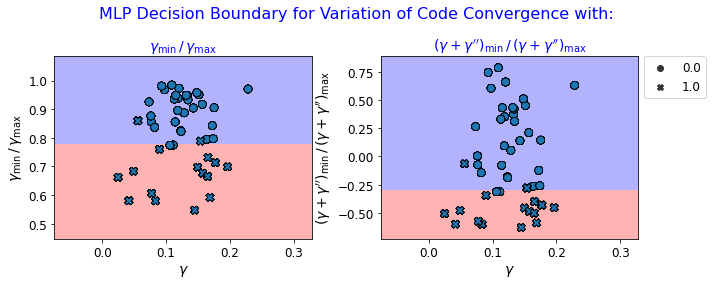

In [28]:
# 1️⃣ Extract Data (Keep orientation classes 0 & 1)
filtered_df = final_df[final_df["short_status"].isin([0, 1])]

# Features (only r_ratio & stiffness_ratio, ignoring gamma)
X_s10 = filtered_df[["r_ratio"]].values  # Use only r_ratio for classification
y_s10 = filtered_df["short_status"].values

X_s11 = filtered_df[["stiffness_ratio"]].values  # Use only stiffness_ratio for classification
y_s11 = filtered_df["short_status"].values

# 2️⃣ Split dataset into training and testing sets
X_train_s10, X_test_s10, y_train_s10, y_test_s10 = train_test_split(X_s10, y_s10, test_size=0.2, random_state=42, stratify=y_s10)
X_train_s11, X_test_s11, y_train_s11, y_test_s11 = train_test_split(X_s11, y_s11, test_size=0.2, random_state=42, stratify=y_s11)

# Normalize data (Only r_ratio & stiffness_ratio)
scaler_s10 = StandardScaler()
X_train_s10 = scaler_s10.fit_transform(X_train_s10)
X_test_s10 = scaler_s10.transform(X_test_s10)

scaler_s11 = StandardScaler()
X_train_s11 = scaler_s11.fit_transform(X_train_s11)
X_test_s11 = scaler_s11.transform(X_test_s11)

# 3️⃣ Train MLP Classifiers (Only on r_ratio and stiffness_ratio, ignoring gamma)
mlp_s10 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu",
                        max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s10.fit(X_train_s10, y_train_s10)

mlp_s11 = MLPClassifier(hidden_layer_sizes=(5, 5), solver="sgd", activation="relu",
                        max_iter=1000, random_state=42, learning_rate_init=0.01)
mlp_s11.fit(X_train_s11, y_train_s11)

# 4️⃣ Generate Meshgrid for Decision Boundaries (Use gamma for visualization, but classification only on y-axis variables)
gamma_min, gamma_max = filtered_df["gamma"].min() - 0.1, filtered_df["gamma"].max() + 0.1
r_ratio_min, r_ratio_max = filtered_df["r_ratio"].min() - 0.1, filtered_df["r_ratio"].max() + 0.1
stiffness_ratio_min, stiffness_ratio_max = filtered_df["stiffness_ratio"].min() - 0.1, filtered_df["stiffness_ratio"].max() + 0.1

xx_s10, yy_s10 = np.meshgrid(np.linspace(gamma_min, gamma_max, 100),
                           np.linspace(r_ratio_min, r_ratio_max, 100))

xx_s11, yy_s11 = np.meshgrid(np.linspace(gamma_min, gamma_max, 100),
                           np.linspace(stiffness_ratio_min, stiffness_ratio_max, 100))

# Predict decision boundaries (Only use y-axis variables for classification)
Z_s10 = mlp_s10.predict(scaler_s10.transform(yy_s10.ravel().reshape(-1, 1))).reshape(xx_s10.shape)
Z_s11 = mlp_s11.predict(scaler_s11.transform(yy_s11.ravel().reshape(-1, 1))).reshape(xx_s11.shape)

# ✅ Debugging: Ensure classifier predicts two classes
print("Unique Z_s10 classes:", np.unique(Z_s10))
print("Unique Z_s11 classes:", np.unique(Z_s11))

# 5️⃣ Plot Subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(r"MLP Decision Boundary for Variation of Code Convergence with:",size=16,color="blue")

# Custom colormap for two classes
cmap_custom = colors.ListedColormap(["blue", "red"])

# (Left) Decision Boundary for r_ratio (Ignoring gamma in classification)
axes[0].contourf(xx_s10, yy_s10, Z_s10, alpha=0.3, cmap=cmap_custom)
sns.scatterplot(data=filtered_df, x="gamma", y="r_ratio", style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[0])
axes[0].set_title(r'$\gamma_{\min}\, / \, \gamma_{\max}$' )
axes[0].set_xlabel(r"$\gamma$")
axes[0].set_ylabel(r'$\gamma_{\min} \, / \, \gamma_{\max}$')

# (Right) Decision Boundary for Stiffness Ratio (Ignoring gamma in classification)
axes[1].contourf(xx_s11, yy_s11, Z_s11, alpha=0.3, cmap=cmap_custom)
sns.scatterplot(data=filtered_df, x="gamma", y="stiffness_ratio",  style="short_status", 
                s=60, edgecolor="black", palette="deep", ax=axes[1])
axes[1].set_title(r'$(\gamma + \gamma^{\prime\prime})_{\min} \, / \, (\gamma + \gamma^{\prime\prime})_{\max}$')
axes[1].set_xlabel(r"$\gamma$")
axes[1].set_ylabel(r'$(\gamma + \gamma^{\prime\prime})_{\min} \, / \, (\gamma + \gamma^{\prime\prime})_{\max}$')

# Adjust Legends
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0].legend_.remove()

plt.tight_layout()
plt.savefig( f"figures/convergence_gamma.png", dpi=1200,bbox_inches='tight', facecolor='white')

plt.show()


In [29]:
num_division=7
V_min,V_max=minmax(V)
v_min2=my_ceil(V_min,2)
v_max2=my_floor(V_max,2)
dt=my_ceil(((v_max2-v_min2)/float(num_division-1)),2)
print(v_min2,v_max2,dt)
v_range=np.arange(v_min2,v_max2+dt,dt)
print(v_range)

0.78 4.24 0.58
[0.78 1.36 1.94 2.52 3.1  3.68 4.26]


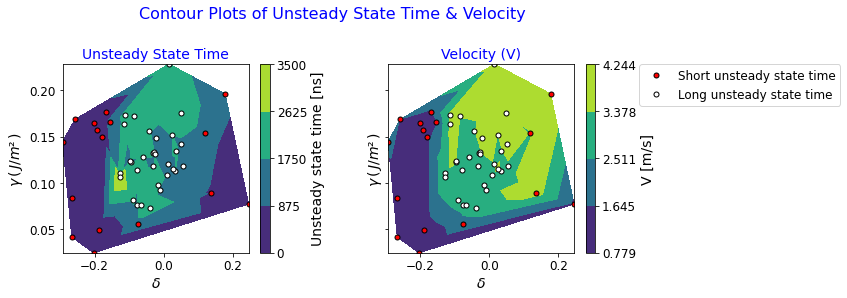

In [30]:
# Define limits for contour levels
Unsteady_time_min, Unsteady_time_max = minmax(Unsteady_time)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plt.subplots_adjust(top=0.78,wspace=0.4)

# 🔹 (Left) Contour Plot: Unsteady Time
levels_ut = np.linspace(Unsteady_time_min, Unsteady_time_max, 5)
axes[0].plot(delta_short, gamma_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0].plot(delta_long, gamma_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0].tricontourf(delta, gamma, Unsteady_time, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0], label="Unsteady state time [ns]")

axes[0].set_xlabel(r"$\delta$")
axes[0].set_ylabel(r"$\gamma \,(\,J/m²\,)$")
axes[0].set_title("Unsteady State Time")

# 🔹 (Right) Contour Plot: Velocity (V)
levels_v = np.linspace(V_min, V_max, 5)
axes[1].plot(delta_short, gamma_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1].plot(delta_long, gamma_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_v = axes[1].tricontourf(delta, gamma, V, levels=levels_v)
cbar_v = fig.colorbar(contour_v, ax=axes[1], label="V [m/s]")

axes[1].set_xlabel(r"$\delta$")
axes[1].set_ylabel(r"$\gamma \,(\,J/m²\,)$")
axes[1].set_title("Velocity (V)")
axes[1].legend(bbox_to_anchor=(1.35, 1), loc='upper left', borderaxespad=0, ncol=1)

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of Unsteady State Time & Velocity",size=16,color="blue")
plt.savefig('figures/merged_Unsteady_time_V.png', dpi=1200, bbox_inches='tight')
plt.show()


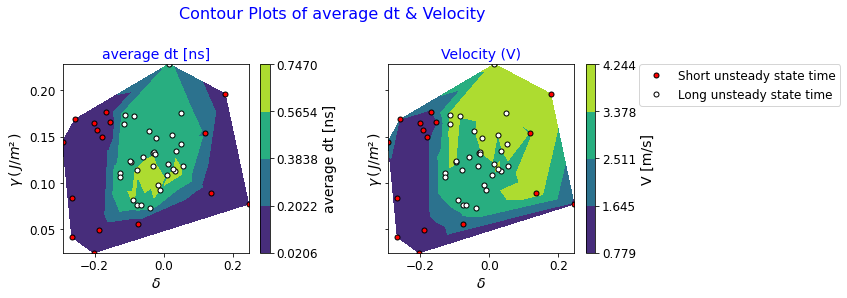

In [31]:
# Define limits for contour levels
average_dt_min, average_dt_max = minmax(average_dt)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plt.subplots_adjust(top=0.78,wspace=0.4)

# 🔹 (Left) Contour Plot: Unsteady Time
levels_ut = np.linspace(average_dt_min, average_dt_max, 5)
axes[0].plot(delta_short, gamma_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0].plot(delta_long, gamma_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0].tricontourf(delta, gamma, average_dt, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0], label="average dt [ns]")

axes[0].set_xlabel(r"$\delta$")
axes[0].set_ylabel(r"$\gamma \,(\,J/m²\,)$")
axes[0].set_title("average dt [ns]")

# 🔹 (Right) Contour Plot: Velocity (V)
levels_v = np.linspace(V_min, V_max, 5)
axes[1].plot(delta_short, gamma_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1].plot(delta_long, gamma_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_v = axes[1].tricontourf(delta, gamma, V, levels=levels_v)
cbar_v = fig.colorbar(contour_v, ax=axes[1], label="V [m/s]")

axes[1].set_xlabel(r"$\delta$")
axes[1].set_ylabel(r"$\gamma \,(\,J/m²\,)$")
axes[1].set_title("Velocity (V)")
axes[1].legend(bbox_to_anchor=(1.35, 1), loc='upper left', borderaxespad=0, ncol=1)

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of average dt & Velocity",size=16,color="blue")
plt.savefig('figures/merged_average_dt_V.png', dpi=1200, bbox_inches='tight')
plt.show()


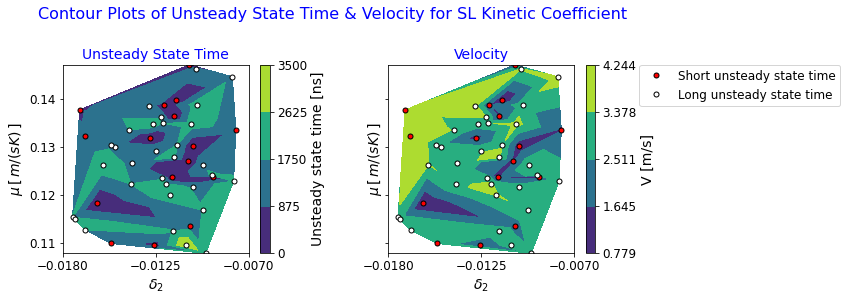

In [32]:
# Define limits for contour levels
Unsteady_time_min, Unsteady_time_max = minmax(Unsteady_time)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plt.subplots_adjust(top=0.78,wspace=0.4)

# 🔹 (Left) Contour Plot: Unsteady Time
levels_ut = np.linspace(Unsteady_time_min, Unsteady_time_max, 5)
axes[0].plot(delta2_short, mu_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0].plot(delta2_long, mu_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0].tricontourf(delta2, mu, Unsteady_time, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0], label="Unsteady state time [ns]")

axes[0].set_xlabel(r"$ \delta_2 $")
axes[0].set_ylabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[0].set_title("Unsteady State Time")

# 🔹 (Right) Contour Plot: Velocity (V)
levels_v = np.linspace(V_min, V_max, 5)
axes[1].plot(delta2_short, mu_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1].plot(delta2_long, mu_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_v = axes[1].tricontourf(delta2, mu, V, levels=levels_v)
cbar_v = fig.colorbar(contour_v, ax=axes[1], label="V [m/s]")

axes[1].set_xlabel(r"$ \delta_2 $")
axes[1].set_ylabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[1].set_title("Velocity")
axes[1].legend(bbox_to_anchor=(1.35, 1), loc='upper left', borderaxespad=0, ncol=1)
for ax in axes:
    ax.set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of Unsteady State Time & Velocity for SL Kinetic Coefficient", color="blue",size=16)
plt.savefig('figures/merged_Unsteady_time_V_mu_delta2.png', dpi=1200, bbox_inches='tight')
plt.show()


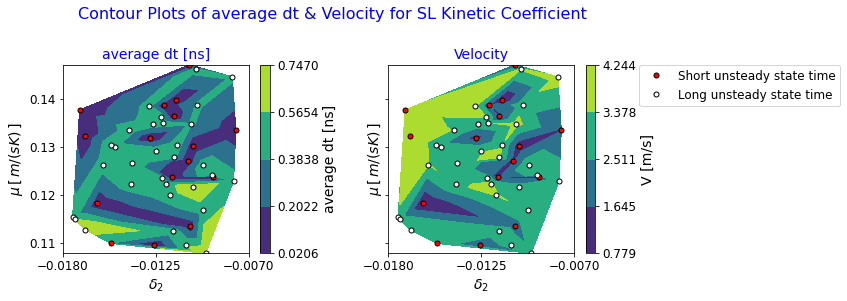

In [33]:
# Define limits for contour levels
average_dt_min, average_dt_max = minmax(average_dt)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plt.subplots_adjust(top=0.78,wspace=0.4)

# 🔹 (Left) Contour Plot: Unsteady Time
levels_ut = np.linspace(average_dt_min, average_dt_max, 5)
axes[0].plot(delta2_short, mu_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0].plot(delta2_long, mu_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0].tricontourf(delta2, mu, average_dt, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0], label="average dt [ns]")

axes[0].set_xlabel(r"$ \delta_2 $")
axes[0].set_ylabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[0].set_title("average dt [ns]")

# 🔹 (Right) Contour Plot: Velocity (V)
levels_v = np.linspace(V_min, V_max, 5)
axes[1].plot(delta2_short, mu_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1].plot(delta2_long, mu_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_v = axes[1].tricontourf(delta2, mu, V, levels=levels_v)
cbar_v = fig.colorbar(contour_v, ax=axes[1], label="V [m/s]")

axes[1].set_xlabel(r"$ \delta_2 $")
axes[1].set_ylabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[1].set_title("Velocity")
axes[1].legend(bbox_to_anchor=(1.35, 1), loc='upper left', borderaxespad=0, ncol=1)
for ax in axes:
    ax.set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of average dt & Velocity for SL Kinetic Coefficient", color="blue",size=16)
plt.savefig('figures/merged_average_dt_V_mu_delta2.png', dpi=1200, bbox_inches='tight')
plt.show()


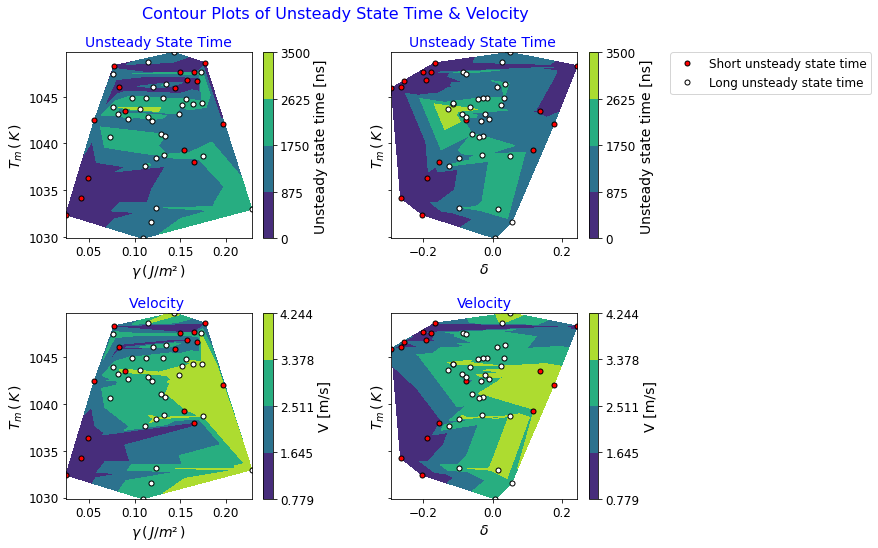

In [34]:
# Define limits for contour levels
Unsteady_time_min, Unsteady_time_max = minmax(Unsteady_time)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
plt.subplots_adjust(top=0.90, wspace=0.4, hspace=0.4)  # Adjust spacing

# 🔹 (1,1) Contour Plot: Unsteady Time (Tm vs Gamma)
levels_ut = np.linspace(Unsteady_time_min, Unsteady_time_max, 5)
axes[0, 0].plot(gamma_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 0].plot(gamma_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0, 0].tricontourf(gamma, Tm, Unsteady_time, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0, 0], label="Unsteady state time [ns]")

axes[0, 0].set_xlabel(r"$\gamma \,(\,J/m²\,)$")
axes[0, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 0].set_title("Unsteady State Time")

# 🔹 (1,2) Contour Plot: Unsteady Time (Tm vs Delta)
axes[0, 1].plot(delta_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 1].plot(delta_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_tm = axes[0, 1].tricontourf(delta, Tm, Unsteady_time, levels=levels_ut)
cbar_tm = fig.colorbar(contour_tm, ax=axes[0, 1], label="Unsteady state time [ns]")

axes[0, 1].set_xlabel(r"$\delta$")
axes[0, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 1].set_title("Unsteady State Time ")

# 🔹 (2,1) Contour Plot: Velocity (Tm vs Gamma)
levels_v = np.linspace(V_min, V_max, 5)
axes[1, 0].plot(gamma_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 0].plot(gamma_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vg = axes[1, 0].tricontourf(gamma, Tm, V, levels=levels_v)
cbar_vg = fig.colorbar(contour_vg, ax=axes[1, 0], label="V [m/s]")

axes[1, 0].set_xlabel(r"$\gamma \,(\,J/m²\,)$")
axes[1, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 0].set_title("Velocity ")

# 🔹 (2,2) Contour Plot: Velocity (Tm vs Delta)
axes[1, 1].plot(delta_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 1].plot(delta_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vd = axes[1, 1].tricontourf(delta, Tm, V, levels=levels_v)
cbar_vd = fig.colorbar(contour_vd, ax=axes[1, 1], label="V [m/s]")

axes[1, 1].set_xlabel(r"$\delta$")
axes[1, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 1].set_title("Velocity")

# 🔹 Adjust Legends
axes[0, 1].legend(bbox_to_anchor=(1.5, 1), loc='upper left', borderaxespad=0, ncol=1)

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of Unsteady State Time & Velocity", size=16, color="blue")
plt.savefig('figures/merged_Unsteady_time_V_Tm.png', dpi=1200, bbox_inches='tight')
plt.show()


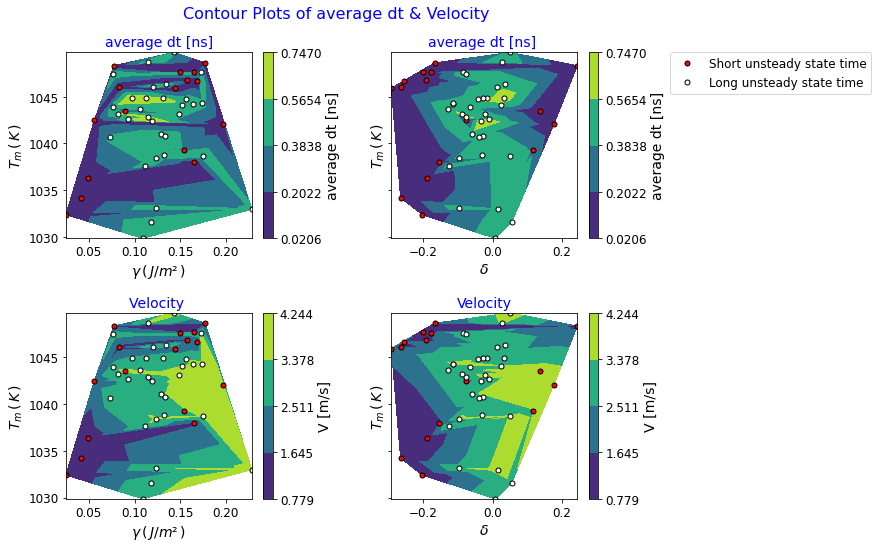

In [35]:
# Define limits for contour levels
average_dt_min, average_dt_max = minmax(average_dt)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
plt.subplots_adjust(top=0.90, wspace=0.4, hspace=0.4)  # Adjust spacing

# 🔹 (1,1) Contour Plot: Unsteady Time (Tm vs Gamma)
levels_ut = np.linspace(average_dt_min, average_dt_max, 5)
axes[0, 0].plot(gamma_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 0].plot(gamma_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0, 0].tricontourf(gamma, Tm, average_dt, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0, 0], label="average dt [ns]")

axes[0, 0].set_xlabel(r"$\gamma \,(\,J/m²\,)$")
axes[0, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 0].set_title("average dt [ns]")

# 🔹 (1,2) Contour Plot: Unsteady Time (Tm vs Delta)
axes[0, 1].plot(delta_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 1].plot(delta_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_tm = axes[0, 1].tricontourf(delta, Tm, average_dt, levels=levels_ut)
cbar_tm = fig.colorbar(contour_tm, ax=axes[0, 1], label="average dt [ns]")

axes[0, 1].set_xlabel(r"$\delta$")
axes[0, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 1].set_title("average dt [ns] ")

# 🔹 (2,1) Contour Plot: Velocity (Tm vs Gamma)
levels_v = np.linspace(V_min, V_max, 5)
axes[1, 0].plot(gamma_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 0].plot(gamma_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vg = axes[1, 0].tricontourf(gamma, Tm, V, levels=levels_v)
cbar_vg = fig.colorbar(contour_vg, ax=axes[1, 0], label="V [m/s]")

axes[1, 0].set_xlabel(r"$\gamma \,(\,J/m²\,)$")
axes[1, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 0].set_title("Velocity ")

# 🔹 (2,2) Contour Plot: Velocity (Tm vs Delta)
axes[1, 1].plot(delta_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 1].plot(delta_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vd = axes[1, 1].tricontourf(delta, Tm, V, levels=levels_v)
cbar_vd = fig.colorbar(contour_vd, ax=axes[1, 1], label="V [m/s]")

axes[1, 1].set_xlabel(r"$\delta$")
axes[1, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 1].set_title("Velocity")

# 🔹 Adjust Legends
axes[0, 1].legend(bbox_to_anchor=(1.5, 1), loc='upper left', borderaxespad=0, ncol=1)

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of average dt & Velocity", size=16, color="blue")
plt.savefig('figures/merged_average_dt_V_Tm.png', dpi=1200, bbox_inches='tight')
plt.show()


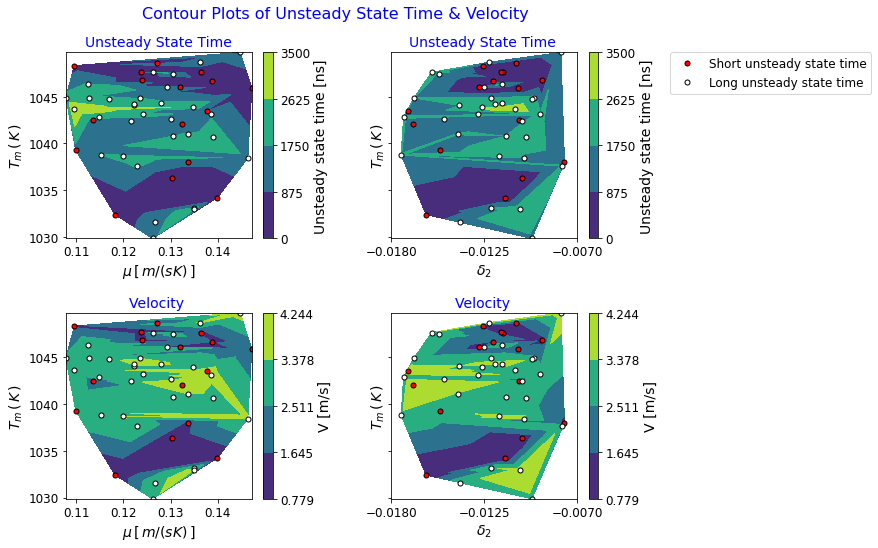

In [36]:
# Define limits for contour levels
Unsteady_time_min, Unsteady_time_max = minmax(Unsteady_time)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
plt.subplots_adjust(top=0.90, wspace=0.4, hspace=0.4)  # Adjust spacing

# 🔹 (1,1) Contour Plot: Unsteady Time (Tm vs Mu)
levels_ut = np.linspace(Unsteady_time_min, Unsteady_time_max, 5)
axes[0, 0].plot(mu_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 0].plot(mu_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0, 0].tricontourf(mu, Tm, Unsteady_time, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0, 0], label="Unsteady state time [ns]")

axes[0, 0].set_xlabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[0, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 0].set_title("Unsteady State Time")

# 🔹 (1,2) Contour Plot: Unsteady Time (Tm vs Delta2)
axes[0, 1].plot(delta2_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 1].plot(delta2_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_tm = axes[0, 1].tricontourf(delta2, Tm, Unsteady_time, levels=levels_ut)
cbar_tm = fig.colorbar(contour_tm, ax=axes[0, 1], label="Unsteady state time [ns]")

axes[0, 1].set_xlabel(r"$\delta_2$")
axes[0, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 1].set_title("Unsteady State Time ")

# 🔹 (2,1) Contour Plot: Velocity (Tm vs Mu)
levels_v = np.linspace(V_min, V_max, 5)
axes[1, 0].plot(mu_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 0].plot(mu_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vg = axes[1, 0].tricontourf(mu, Tm, V, levels=levels_v)
cbar_vg = fig.colorbar(contour_vg, ax=axes[1, 0], label="V [m/s]")

axes[1, 0].set_xlabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[1, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 0].set_title("Velocity ")

# 🔹 (2,2) Contour Plot: Velocity (Tm vs Delta2)
axes[1, 1].plot(delta2_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 1].plot(delta2_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vd = axes[1, 1].tricontourf(delta2, Tm, V, levels=levels_v)
cbar_vd = fig.colorbar(contour_vd, ax=axes[1, 1], label="V [m/s]")

axes[1, 1].set_xlabel(r"$\delta_2$")
axes[1, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 1].set_title("Velocity ")

# 🔹 Adjust Legends
axes[0, 1].legend(bbox_to_anchor=(1.5, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0, 1].set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels
axes[1, 1].set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of Unsteady State Time & Velocity", size=16, color="blue")
plt.savefig('figures/merged_Unsteady_time_V_Tm.png', dpi=1200, bbox_inches='tight')
plt.show()


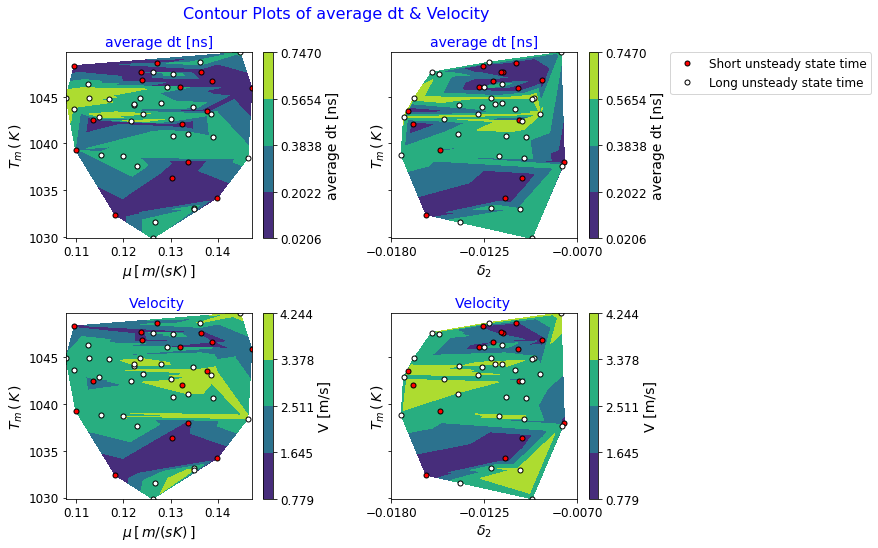

In [37]:
# Define limits for contour levels
average_dt_min, average_dt_max = minmax(average_dt)
V_min, V_max = minmax(V)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
plt.subplots_adjust(top=0.90, wspace=0.4, hspace=0.4)  # Adjust spacing

# 🔹 (1,1) Contour Plot: Unsteady Time (Tm vs Mu)
levels_ut = np.linspace(average_dt_min, average_dt_max, 5)
axes[0, 0].plot(mu_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 0].plot(mu_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_ut = axes[0, 0].tricontourf(mu, Tm, average_dt, levels=levels_ut)
cbar_ut = fig.colorbar(contour_ut, ax=axes[0, 0], label="average dt [ns]")

axes[0, 0].set_xlabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[0, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 0].set_title("average dt [ns]")

# 🔹 (1,2) Contour Plot: Unsteady Time (Tm vs Delta2)
axes[0, 1].plot(delta2_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[0, 1].plot(delta2_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_tm = axes[0, 1].tricontourf(delta2, Tm, average_dt, levels=levels_ut)
cbar_tm = fig.colorbar(contour_tm, ax=axes[0, 1], label="average dt [ns]")

axes[0, 1].set_xlabel(r"$\delta_2$")
axes[0, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[0, 1].set_title("average dt [ns]")

# 🔹 (2,1) Contour Plot: Velocity (Tm vs Mu)
levels_v = np.linspace(V_min, V_max, 5)
axes[1, 0].plot(mu_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 0].plot(mu_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vg = axes[1, 0].tricontourf(mu, Tm, V, levels=levels_v)
cbar_vg = fig.colorbar(contour_vg, ax=axes[1, 0], label="V [m/s]")

axes[1, 0].set_xlabel(r"$ \mu \, [\, m/(sK)\,]$")
axes[1, 0].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 0].set_title("Velocity ")

# 🔹 (2,2) Contour Plot: Velocity (Tm vs Delta2)
axes[1, 1].plot(delta2_short, Tm_short, 'o', markersize=5, color='red', markeredgecolor="black", label="Short unsteady state time")
axes[1, 1].plot(delta2_long, Tm_long, 'o', markersize=5, color='white', markeredgecolor="black", label="Long unsteady state time")

contour_vd = axes[1, 1].tricontourf(delta2, Tm, V, levels=levels_v)
cbar_vd = fig.colorbar(contour_vd, ax=axes[1, 1], label="V [m/s]")

axes[1, 1].set_xlabel(r"$\delta_2$")
axes[1, 1].set_ylabel(r"$T_m \,(\,K\,)$")
axes[1, 1].set_title("Velocity ")

# 🔹 Adjust Legends
axes[0, 1].legend(bbox_to_anchor=(1.5, 1), loc='upper left', borderaxespad=0, ncol=1)
axes[0, 1].set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels
axes[1, 1].set_xticks([np.floor(min(delta2)*1000)/1000, 0.5*(np.floor(min(delta2)*1000)/1000+np.ceil(max(delta2)*1000)/1000),np.ceil(max(delta2)*1000)/1000])  # Ensure 5 evenly spaced x-axis labels

# 🔹 Save and Show the Figure
plt.suptitle("Contour Plots of average dt & Velocity", size=16, color="blue")
plt.savefig('figures/merged_average_dt_V_Tm.png', dpi=1200, bbox_inches='tight')
plt.show()


In [38]:
xx=data_cor[['SL interface free energy anisotropy', 'SL interface free energy']] 
#print(x)
yy=data_cor[["short_status"]]
delta_min=data_cor["SL interface free energy anisotropy"].min()
delta_max=data_cor["SL interface free energy anisotropy"].max()
gamma_min=data_cor['SL interface free energy'].min()
gamma_max=data_cor['SL interface free energy'].max()
print(delta_min)
print(delta_max)
print(gamma_min)
print(gamma_max)

-0.29243
0.24514299
0.024823
0.22841719


In [39]:
x_train, x_test, y_train, y_test= train_test_split(xx, yy, test_size=0.2, random_state=97890)
tmp = x_train
x_train_original=tmp
tmp2 = x_test
x_test_original=tmp2
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test= scaler.transform(x_test)


print(x_train.shape)
print(y_train.shape)

(37, 2)
(37, 1)


In [40]:
min_test_gamma=min(x_test[:,1])
min_train_gamma=min(x_train[:,1])
min_test_delta=min(x_test[:,0])
min_train_delta=min(x_train[:,0])

max_test_gamma=max(x_test[:,1])
max_train_gamma=max(x_train[:,1])
max_test_delta=max(x_test[:,0])
max_train_delta=max(x_train[:,0])
min_gamma=min(min_test_gamma,min_train_gamma)
max_gamma=max(max_test_gamma,max_train_gamma)
min_delta=min(min_test_delta,min_train_delta)
max_delta=max(max_test_delta,max_train_delta)
print(min_gamma,max_gamma)
print(min_delta,max_delta)

-2.5260470493713214 2.503778406063472
-1.872580710999906 2.5089913328057207


first 0
clf_0
Cross-validation accuracy scores: [1.         1.         1.         1.         1.         1.
 1.         1.         0.66666667 1.        ]
Mean accuracy: 0.9667 ± 0.1000
37
second 1


<Figure size 432x288 with 0 Axes>

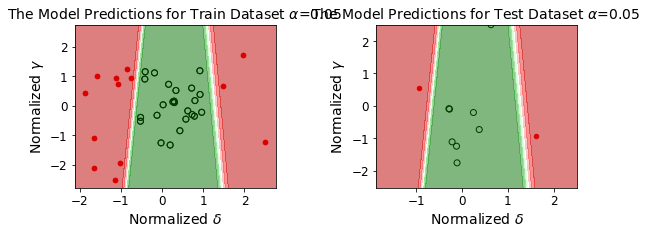

In [41]:
plt.clf()
fig, axs = plt.subplots(1, 2,figsize=(9, 3)) #, 
fig.subplots_adjust(wspace=0.5,hspace=0.5)
axs = axs.ravel()


c = [ "darkgreen","green","palegreen","white","lightcoral","red","darkred"]
v = [0,.167,0.334,0.501,0.668,0.835,1.]
l = list(zip(v,c))
cmap_rg2=LinearSegmentedColormap.from_list('rg',l, N=256)



alpha=[0.05] 
counter_tmp=0
cc=0
for ii in range(len(alpha)):
    print("first",cc)
    name="clf_"+str(counter_tmp)
    print(name)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    name = MLPClassifier(solver='lbfgs', alpha=alpha[ii],hidden_layer_sizes=(5, 5), random_state=1)
    cv_scores = cross_val_score(name, x_train, y_train, cv=cv, scoring='accuracy')

    # Print cross-validation results
    print(f"Cross-validation accuracy scores: {cv_scores}")
    print(f"Mean accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
    name.fit(x_train,y_train)
    y_pred=name.predict(x_train)

    x0=[];x1=[];y0=[];y1=[];
    row_num=[]
    counter=0
    print(len(y_train))
    for i in range(len(y_train)):
        if (y_pred[i]==0.0):
            x0.append(x_train[i,0].item())
            y0.append(x_train[i,1].item())
        elif (y_pred[i]==1.0):
            x1.append(x_train[i,0].item())
            y1.append(x_train[i,1].item()) 
    axs[cc].scatter(x1, y1 , label="short unsteady state time",color='red',s=20 ) #pred_2
    axs[cc].scatter(x0, y0 , label="long unsteady state time",color='black',facecolor='none'  ) #pred_2
#    x0_orig, y0_orig = scaler.inverse_transform(np.column_stack((x0, y0))).T
#    x1_orig, y1_orig = scaler.inverse_transform(np.column_stack((x1, y1))).T

    axs[cc].scatter(x1, y1 , label="short unsteady state time",color='red',s=20 ) #pred_2
    axs[cc].scatter(x0, y0 , label="long unsteady state time",color='black',facecolor='none'  ) #pred_2


    h = 0.002  # step size in the mesh
    x_min, x_max = min_delta-0.25 , max_delta+0.25
    y_min, y_max = min_gamma-0.25 , max_gamma+0.25
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    
    if hasattr(name, "decision_function"):
        Z = name.decision_function(np.column_stack([xx.ravel(), yy.ravel()]))
    else:
        Z = name.predict_proba(np.column_stack([xx.ravel(), yy.ravel()]))[:, 1]

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)
        axs[cc].contourf(xx, yy, Z, alpha=0.5, cmap=cmap_rg2) #plt.cm.RdBu

    score=name.score(x_train, y_pred)
    axs[cc].title.set_text("The Model Predictions for Train Dataset "+ r'$\alpha$'+"={} ".format(alpha[ii])) #with a testing score of {} | ,round(score,4)

    axs[cc].set_xlabel("Normalized "+r'$\delta$')
    axs[cc].set_ylabel("Normalized "+r'$\gamma$')
#    axs[cc].set_xlim(min_delta,max_delta)    
#    axs[cc].set_ylim(min_gamma,max_gamma)  
    
    cc+=1
    print("second",cc)
    y_pred=name.predict(x_test)

    x0=[];x1=[];y0=[];y1=[];
    row_num=[]
    counter=0
    for i in range(len(y_test)):
        if (y_pred[i]==0.0):
            x0.append(x_test[i,0].item())
            y0.append(x_test[i,1].item())
        elif (y_pred[i]==1.0):
            x1.append(x_test[i,0].item())
            y1.append(x_test[i,1].item()) 
    axs[cc].scatter(x1, y1 , label="short unsteady state time",color='red',s=20 ) #pred_2
    axs[cc].scatter(x0, y0 , label="long unsteady state time",color='black',facecolor='none'  ) #pred_2


    h = 0.002 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    
    if hasattr(name, "decision_function"):
        Z = name.decision_function(np.column_stack([xx.ravel(), yy.ravel()]))
    else:
        Z = name.predict_proba(np.column_stack([xx.ravel(), yy.ravel()]))[:, 1]
        Z = Z.reshape(xx.shape)
        axs[cc].contourf(xx, yy, Z, alpha=0.5, cmap=cmap_rg2) #plt.cm.RdBu





    score=name.score(x_test, y_pred)
    axs[cc].title.set_text("The Model Predictions for Test Dataset "+ r'$\alpha$'+"={} ".format(alpha[ii])) #with a testing score of {} | ,round(score,4)

    axs[cc].set_xlabel("Normalized "+r'$\delta$')
    axs[cc].set_ylabel("Normalized "+r'$\gamma$')
    axs[cc].set_xlim(min_delta,max_delta)    
    axs[cc].set_ylim(min_gamma,max_gamma)    
    
    cc+=1
    
    
    counter_tmp+=1


<Figure size 432x288 with 0 Axes>

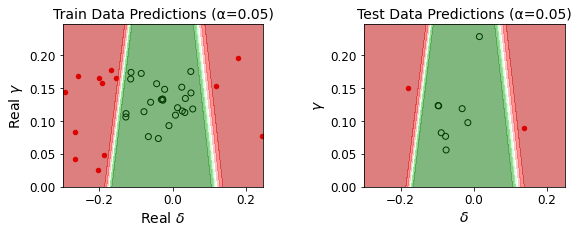

In [42]:
# Get min/max values in the original scale
# Set up plots
plt.clf()
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
fig.subplots_adjust(wspace=0.5, hspace=0.5)
axs = axs.ravel()

c = ["darkgreen", "green", "palegreen", "white", "lightcoral", "red", "darkred"]
v = [0, .167, 0.334, 0.501, 0.668, 0.835, 1.]
cmap_rg2 = LinearSegmentedColormap.from_list('rg', list(zip(v, c)), N=256)

alpha = [0.05]
cc = 0

for ii in range(len(alpha)):
#    name = MLPClassifier(solver='lbfgs', alpha=alpha[ii], hidden_layer_sizes=(5, 2), random_state=1)
#    name.fit(x_train, y_train)
    y_pred_train = name.predict(x_train)

    x0, y0, x1, y1 = [], [], [], []

    for i in range(len(y_train)):
        if y_pred_train[i] == 0.0:
            x0.append(x_train[i, 0])
            y0.append(x_train[i, 1])
        else:
            x1.append(x_train[i, 0])
            y1.append(x_train[i, 1])

    # Convert back to original scale
    x0_real, y0_real = scaler.inverse_transform(np.column_stack((x0, y0))).T
    x1_real, y1_real = scaler.inverse_transform(np.column_stack((x1, y1))).T

    axs[cc].scatter(x1_real, y1_real, label="short unsteady state time", color='red', s=20)
    axs[cc].scatter(x0_real, y0_real, label="long unsteady state time", color='black', facecolor='none')

    # Decision boundary (real scale)
    h = 0.002
#    xx, yy = np.meshgrid(np.arange(delta_min - 0.05, delta_max + 0.05, h),
#                         np.arange(gamma_min - 0.05, gamma_max + 0.05, h))
    xx, yy = np.meshgrid(np.arange(-0.3, 0.25, h),
                         np.arange(0, 0.25, h))
    xy_scaled = scaler.transform(np.column_stack([xx.ravel(), yy.ravel()]))

    Z = name.predict_proba(xy_scaled)[:, 1].reshape(xx.shape)
    axs[cc].contourf(xx, yy, Z, alpha=0.5, cmap=cmap_rg2)

    axs[cc].title.set_text(f"Train Data Predictions (α={alpha[ii]})")
    axs[cc].set_xlabel("Real " + r'$\delta$')
    axs[cc].set_ylabel("Real " + r'$\gamma$')

    cc += 1

    # Predict on test set
    y_pred_test = name.predict(x_test)

    x0, y0, x1, y1 = [], [], [], []

    for i in range(len(y_test)):
        if y_pred_test[i] == 0.0:
            x0.append(x_test[i, 0])
            y0.append(x_test[i, 1])
        else:
            x1.append(x_test[i, 0])
            y1.append(x_test[i, 1])
    x0_real, y0_real = scaler.inverse_transform(np.column_stack((x0, y0))).T
    x1_real, y1_real = scaler.inverse_transform(np.column_stack((x1, y1))).T

    axs[cc].scatter(x1_real, y1_real, label="short unsteady state time", color='red', s=20)
    axs[cc].scatter(x0_real, y0_real, label="long unsteady state time", color='black', facecolor='none')

    # Decision boundary (real scale)
    xy_scaled = scaler.transform(np.column_stack([xx.ravel(), yy.ravel()]))
    Z = name.predict_proba(xy_scaled)[:, 1].reshape(xx.shape)
    axs[cc].contourf(xx, yy, Z, alpha=0.5, cmap=cmap_rg2)

    axs[cc].title.set_text(f"Test Data Predictions (α={alpha[ii]})")
    axs[cc].set_xlabel(r'$\delta$')
    axs[cc].set_ylabel( r'$\gamma$')

    cc += 1
